# Replicating Oliveira et al. (2025): Macroeconomic Regime Detection and Tactical Asset Allocation

**Reference paper.** Oliveira, D. C., Sandfelder, D., Fujita, A., Dong, X., and Cucuringu, M. (2025). *Tactical Asset Allocation with Macroeconomic Regime Detection.* arXiv:2503.11499v2.

**Companion reference.** McCracken, M. W., and Ng, S. (2016). *FRED-MD: A monthly database for macroeconomic research.* Journal of Business and Economic Statistics, 34(4), 574-589. (Cited below as "MN16".)

---

## What this notebook does

This notebook replicates **Sections 3 through 6** of the paper, end to end:

| Part | Paper sections | What we build |
|---|---|---|
| **Part A: regime detection** | 3, 4 | Modified k-means, soft probabilities, transition matrix, regime characterization, GMM comparison |
| **Part B: tactical asset allocation** | 5, 6 | Walk-forward backtest with Naive / BL / Ridge forecasters, four sizing schemes, MVO and equal-weight benchmarks |

We use the **FRED-MD vintage released in February 2023** (file `2023-02.csv`), which contains macro data through January 2023. This matches the paper's stated coverage (December 1959 to January 2023, paper Section 4.1).



## 1. Setup

In [366]:
# Standard imports
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from scipy.optimize import linear_sum_assignment
from scipy.stats import ttest_rel

# Suppress benign log warnings (some FRED-MD series have non-positive entries
# that produce NaNs after t-code transforms; we drop them later anyway).
warnings.filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in log')
warnings.filterwarnings('ignore', category=RuntimeWarning, message='divide by zero encountered in log')

# Reproducibility
RANDOM_SEED = 1
np.random.seed(RANDOM_SEED)

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

# Paths - adjust these to match your local file layout if needed.
# We use the FRED-MD vintage whose final observation is January 2023, so the
# coverage matches the paper Section 4.1 statement ("December 1959 to January 2023").
# Note: the FRED-MD file naming convention is year-month-of-the-vintage-release,
# so the file containing data through Jan-2023 is named 2023-02 (released Feb 2023).
FREDMD_PATH = './data/fredmd/2023-02.csv'
ETF_PATH = './data/etf_wrds/etf_monthly_returns.csv'

# Paper parameters
ETF_TICKERS = ['SPY', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']
ESTIMATION_WINDOW = 48        # paper Section 6: "estimation window of 48 months"
N_TYPICAL_REGIMES = 5         # paper Section 4.2: r = 5 from elbow heuristic
PCA_VAR_THRESHOLD = 0.95      # paper Section 4.2: 95% variance threshold

PAPER_MACRO_START = '1959-12-01'
PAPER_MACRO_END = '2023-01-01'

PAPER_ETF_START = '2000-02-01'
PAPER_ETF_END = '2022-12-01'

# Important:
# The paper text says Group 6 is excluded, but Figure 4 uses FEDFUNDS,
# and with the supplied 2023-02 vintage the reported 61 PCA components
# are matched only when Group 6 is kept.
KEEP_GROUP6_FOR_MAIN_REPLICATION = False

# Quick path sanity check
for label, p in [('FRED-MD', FREDMD_PATH), ('ETFs', ETF_PATH)]:
    if os.path.exists(p):
        print(f'OK   - {label:8s} {p}')
    else:
        print(f'MISS - {label:8s} {p}  (will fail later if needed)')



OK   - FRED-MD  ./data/fredmd/2023-02.csv
OK   - ETFs     ./data/etf_wrds/etf_monthly_returns.csv


---

# Part A: Regime detection (paper Sections 3-4)

We start with the **regime labelling** half of the paper. The output of this part is, for each month $t$, a discrete regime label and a soft probability distribution over regimes. Part B will then use these regimes for portfolio construction.

## 2. Load FRED-MD and apply MN16 transformation codes

**Paper reference.** Section 4.2 ("Data Preparation"): *"most of the variables in the FRED-MD dataset must be transformed before they can be demeaned and standardized... each variable has a t-code assigned to it that corresponds to one of seven possible transformations."*

The seven transformations from MN16 Table 1 are:

| t-code | Transformation | Formula |
|---|---|---|
| 1 | level | $x_t$ |
| 2 | first difference | $\Delta x_t$ |
| 3 | second difference | $\Delta^2 x_t$ |
| 4 | log | $\log x_t$ |
| 5 | log first difference | $\Delta \log x_t$ |
| 6 | log second difference | $\Delta^2 \log x_t$ |
| 7 | growth rate first difference | $\Delta\!\left(\dfrac{x_t}{x_{t-1}} - 1\right)$ |

The transformation codes live in **row 1** of the FRED-MD CSV (the row labelled `Transform:`). The actual time series start from row 2.

We use the **FRED-MD vintage of February 2023** (file `2023-02.csv`), which has data through January 2023. This matches the paper's stated coverage (December 1959 to January 2023, paper Section 4.1) and eliminates vintage drift as a source of replication discrepancy.

**FRED-MD naming convention.** The file is named by the *release month*, not the *last data month*. The vintage released in February 2023 contains data through January 2023, so it is named `2023-02.csv`. This is the standard FRED-MD convention from the Federal Reserve Bank of St. Louis.

The 2023-02 vintage has 126 series; the paper claims 127 variables, which is one off from the actual count (a minor paper inaccuracy, not actionable).

In [367]:
def load_fredmd(path):
    '''
    Load a FRED-MD CSV and return a (data, tcodes) tuple.

    - data:    DataFrame indexed by sasdate (monthly), columns = series, raw levels.
    - tcodes:  Series mapping series_name -> t-code (integer 1..7).

    See MN16 for the t-code definitions.
    '''
    raw = pd.read_csv(path)
    # Row 0 of the data part (index 0 after read_csv) is the 'Transform:' row.
    tcodes = raw.iloc[0, 1:].astype(int)
    tcodes.name = 'tcode'

    # Drop the transform row, parse dates, set index.
    data = raw.iloc[1:].copy()
    data['sasdate'] = pd.to_datetime(data['sasdate'])
    data = data.set_index('sasdate').astype(float)
    data.index.name = 'date'
    return data, tcodes


def apply_tcode(series, code):
    '''Apply the MN16 transformation code to a single series.'''
    s = series.astype(float)
    if code == 1: return s
    if code == 2: return s.diff()
    if code == 3: return s.diff().diff()
    if code == 4: return np.log(s)
    if code == 5: return np.log(s).diff()
    if code == 6: return np.log(s).diff().diff()
    if code == 7: return (s / s.shift(1) - 1.0).diff()
    raise ValueError(f"Unknown t-code: {code}")


def transform_all(data, tcodes):
    '''Apply the right t-code to every column of series.'''
    return pd.DataFrame(
        {col: apply_tcode(data[col], tcodes[col]) for col in data.columns},
        index=data.index,
    )


data_raw, tcodes = load_fredmd(FREDMD_PATH)
data_trans = transform_all(data_raw, tcodes)

print(f"Raw data shape:         {data_raw.shape}")
print(f"Transformed data shape: {data_trans.shape}")
print(f"Date range:             {data_trans.index.min().date()} to {data_trans.index.max().date()}")
print(f"Number of series:       {data_trans.shape[1]}")


Raw data shape:         (769, 126)
Transformed data shape: (769, 126)
Date range:             1959-01-01 to 2023-01-01
Number of series:       126


## 3. Construct macro panel and handle missing values

**Paper reference.** Section 4.1: *"FRED-MD is composed of a variety of groups of variables, namely: (1) Output and Income, (2) Consumption Orders and Inventories, (3) Labor Market, (4) Housing, (5) Money and Credit, (6) Interest and Exchange Rates, (7) Prices. We excluded group 6 to focus only on U.S. macroeconomic data."*

**A small inconsistency worth noting.** The paper says they used **127** variables after excluding group 6, but in the 2023-01 FRED-MD vintage we have 126 series total, and dropping all of group 6 (22 series) leaves **104 series**. The 127 figure is hard to reconcile with the published group structure; one plausible reading is that the authors only excluded the *exchange rate* part of group 6 (the "to focus on U.S. data" rationale matches FX, not interest rates). For maximum fidelity to the paper's stated rationale we follow the **literal text** ("excluded group 6") and drop all 22 group-6 series.

**Missing values.** PCA does not tolerate NaNs. A handful of series have substantial gaps. MN16 themselves use an EM-style imputation; we use a simpler approach:

1. Drop series with more than 10% missing values *after transformation*.
2. Drop the first few rows of the resulting matrix where differencing has left NaNs.

In [368]:
# Group 6 in FRED-MD: Interest and Exchange Rates - excluded per paper Section 4.1.
GROUP_6 = [
    'FEDFUNDS', 'CP3Mx', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA',
    'COMPAPFFx', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM',
    'AAAFFM', 'BAAFFM',
    'TWEXAFEGSMTHx', 'TWEXMMTH', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx',
]

# Foreign-exchange subset of Group 6 to drop in the main replication.
# Following the paper's stated rationale ("focus on U.S. macro data"), we exclude
# only the bilateral foreign-exchange rates and keep the U.S. interest-rate block.
GROUP_6_FX = [
    'EXSZUSx',  # Switzerland / U.S.
    'EXJPUSx',  # Japan / U.S.
    'EXUSUKx',  # U.S. / U.K.
    'EXCAUSx',  # Canada / U.S.
    'TWEXMMTH',
    'TWEXAFEGSMTHx',
]

def em_impute_pca(panel, n_factors=8, max_iter=50, tol=1e-4, verbose=True):
    '''
    EM-style PCA imputation following McCracken & Ng (2016) Section 3.

    Algorithm:
      1. Initialize missing values to column means (= 0 after demean+standardize).
      2. Standardize the (now complete) panel.
      3. Fit PCA with n_factors components.
      4. Reconstruct the panel as the rank-n_factors PCA approximation.
      5. Replace ONLY the missing cells with the reconstruction; observed
         cells stay at their original values.
      6. Repeat from step 2 until factor estimates converge.

    Parameters
    ----------
    panel : DataFrame, T x N, with NaN cells indicating missing values.
    n_factors : int. Number of PCA factors. MN16 use 8 for the full FRED-MD
                panel. We use the same.
    max_iter : int. Maximum EM iterations.
    tol : float. Convergence threshold on the relative Frobenius-norm change
          of the factor matrix between consecutive iterations.
    verbose : bool. Print progress every 5 iterations.

    Returns
    -------
    imputed : DataFrame with no NaN cells, same shape and labels as panel.
    n_iter  : int. Number of iterations actually run.
    '''
    X = panel.values.copy()
    missing_mask = np.isnan(X)
    if not missing_mask.any():
        return panel.copy(), 0

    # Step 1: initialize missing values to column means (computed on observed).
    col_means = np.nanmean(X, axis=0)
    for j in range(X.shape[1]):
        X[missing_mask[:, j], j] = col_means[j]

    prev_factors = None
    converged_iter = None
    for it in range(max_iter):
        # Standardize on current filled panel.
        cur_means = X.mean(axis=0)
        cur_stds = X.std(axis=0, ddof=1)
        cur_stds = np.where(cur_stds == 0, 1.0, cur_stds)
        X_std = (X - cur_means) / cur_stds

        # PCA on the standardized panel.
        pca_em = PCA(n_components=n_factors, random_state=RANDOM_SEED).fit(X_std)
        F = pca_em.transform(X_std)        # factors, shape (T, r)
        Lambda = pca_em.components_.T      # loadings, shape (N, r)

        # Reconstruct rank-r approximation, un-standardize.
        X_std_hat = F @ Lambda.T
        X_hat = X_std_hat * cur_stds + cur_means

        # Replace ONLY missing cells.
        X_new = X.copy()
        X_new[missing_mask] = X_hat[missing_mask]

        # Convergence check.
        if prev_factors is not None:
            change = np.linalg.norm(F - prev_factors) / max(np.linalg.norm(prev_factors), 1e-12)
            if verbose and it % 5 == 0:
                print(f"  EM iter {it}: factor change = {change:.6f}")
            if change < tol:
                if verbose:
                    print(f"  EM converged at iter {it} (change = {change:.6f})")
                X = X_new
                converged_iter = it
                break
        prev_factors = F.copy()
        X = X_new

    if converged_iter is None and verbose:
        print(f"  EM hit max_iter={max_iter} without converging to tol={tol}")

    return pd.DataFrame(X, index=panel.index, columns=panel.columns), (converged_iter or max_iter) + 1

# Build data_panel: drop only the FX subset of Group 6, keep everything else.
# fx_present = [c for c in GROUP_6_FX if c in data_trans.columns]
# print(f"Group 6 FX series found and dropped: {len(fx_present)} ({fx_present})")
# data_panel = data_trans.drop(columns=fx_present)

# Group 6 handling - unchanged from the user's existing logic.
g6_present = [c for c in GROUP_6 if c in data_trans.columns]
print(f"Group 6 series found in this vintage: {len(g6_present)}")

if KEEP_GROUP6_FOR_MAIN_REPLICATION:
    data_panel = data_trans.copy()
    print("Main replication keeps Group 6 because paper Figure 4 uses FEDFUNDS "
          "and the reported 61-PC result is matched only with Group 6 kept.")
else:
    data_panel = data_trans.drop(columns=g6_present)
    print("Main replication excludes Group 6, following the literal text of Section 4.1.")

# Restrict to the paper's stated macro window: Dec 1959 to Jan 2023.
data_panel = data_trans.loc[PAPER_MACRO_START:PAPER_MACRO_END].copy()

# Report what's missing before imputation.
miss_frac = data_panel.isna().mean()
heavy_missing = miss_frac[miss_frac > 0].sort_values(ascending=False)
if len(heavy_missing):
    print(f"\nSeries with missing values to be EM-imputed:")
    for col, frac in heavy_missing.head(10).items():
        print(f"  {col:20s} {frac*100:5.1f}% missing")
    if len(heavy_missing) > 10:
        print(f"  ... and {len(heavy_missing) - 10} other series with smaller gaps.")
print(f"\nTotal missing cells: {int(data_panel.isna().sum().sum())} "
      f"({100*data_panel.isna().mean().mean():.3f}% of all cells)")

# EM imputation following MN16 Section 3.
print("\nRunning EM-PCA imputation (MN16 Section 3)...")
data_clean, n_em_iter = em_impute_pca(data_panel, n_factors=8, max_iter=50, tol=1e-4)
print(f"\nMacro panel used for replication: {data_clean.shape[0]} months x {data_clean.shape[1]} series")
print(f"Date range: {data_clean.index.min().date()} to {data_clean.index.max().date()}")
print(f"Remaining NaNs: {int(data_clean.isna().sum().sum())}  (should be 0)")

# MAX_MISSING_FRAC = 0.05   # 5%; chosen so we drop UMCSENTx/ACOGNO/ANDENOx
#                           # but keep VIXCLSx (~4.1% missing) and finer gaps.

# miss_frac = data_panel.isna().mean()
# heavy_missing = miss_frac[miss_frac > MAX_MISSING_FRAC].sort_values(ascending=False)
# if len(heavy_missing):
#     print(f"\nDropping {len(heavy_missing)} series with > {MAX_MISSING_FRAC*100:.0f}% missing:")
#     for col, frac in heavy_missing.items():
#         print(f"  {col:20s} {frac*100:5.1f}% missing")

# cols_to_keep = miss_frac[miss_frac <= MAX_MISSING_FRAC].index.tolist()
# data_panel_kept = data_panel[cols_to_keep]

# # Drop rows still containing any NaN (leading rows from differencing,
# # pre-VIXCLSx period, etc.)
# data_clean = data_panel_kept.dropna()

# print(f"\nMacro panel used for replication: {data_clean.shape[0]} months x {data_clean.shape[1]} series")
# print(f"Date range: {data_clean.index.min().date()} to {data_clean.index.max().date()}")
# print(f"Remaining NaNs: {int(data_clean.isna().sum().sum())}  (should be 0)")

Group 6 series found in this vintage: 22
Main replication excludes Group 6, following the literal text of Section 4.1.

Series with missing values to be EM-imputed:
  ACOGNO                51.2% missing
  UMCSENTx              28.8% missing
  TWEXAFEGSMTHx         20.8% missing
  ANDENOx               13.1% missing
  VIXCLSx                4.1% missing
  S&P PE ratio           0.4% missing
  CP3Mx                  0.3% missing
  CONSPI                 0.1% missing
  DTCTHFNM               0.1% missing
  DTCOLNVHFNM            0.1% missing
  ... and 13 other series with smaller gaps.

Total missing cells: 915 (0.958% of all cells)

Running EM-PCA imputation (MN16 Section 3)...
  EM iter 5: factor change = 0.011959
  EM iter 10: factor change = 0.003414
  EM iter 15: factor change = 0.001747
  EM iter 20: factor change = 0.001026
  EM iter 25: factor change = 0.000669
  EM iter 30: factor change = 0.000472
  EM iter 35: factor change = 0.000347
  EM iter 40: factor change = 0.000260
  EM

In [369]:
# # Sanity check: confirm imputation is sensible
# # Verify observed values were preserved exactly.
# um_original = data_panel['UMCSENTx']
# um_imputed = data_clean['UMCSENTx']
# observed_mask = um_original.notna()
# max_diff_observed = (um_original[observed_mask] - um_imputed[observed_mask]).abs().max()
# print(f"Max abs difference on OBSERVED UMCSENTx cells (should be 0): {max_diff_observed:.2e}")

# # Compare imputed vs observed scale.
# um_pre1978_em = um_imputed.loc[:'1978-01-01']
# um_post1978 = um_imputed.loc['1978-02-01':]
# print(f"\nUMCSENTx descriptive stats:")
# print(f"  Pre-1978-02 (EM-imputed):  mean={um_pre1978_em.mean():.3f}, std={um_pre1978_em.std():.3f}, "
#       f"unique={um_pre1978_em.nunique()}, n={len(um_pre1978_em)}")
# print(f"  Post-1978-02 (observed):   mean={um_post1978.mean():.3f}, std={um_post1978.std():.3f}, "
#       f"unique={um_post1978.nunique()}, n={len(um_post1978)}")
# print("\n  -> imputed std should be in the same order of magnitude as the observed std,")
# print("     and the imputed series should have many distinct values (not constant).")

# # Visual check.
# fig, ax = plt.subplots(figsize=(12, 3.5))
# ax.plot(data_clean.index, data_clean['UMCSENTx'], color='C0', linewidth=0.8)
# ax.axvline(pd.Timestamp('1978-02-01'), color='red', linestyle='--', alpha=0.6,
#            label='Imputed (pre 1978-02) | Observed (1978-02 onwards)')
# ax.set_title('UMCSENTx after t-code differencing and EM-PCA imputation')
# ax.set_ylabel('Value (transformed scale)')
# ax.legend(loc='best')
# plt.tight_layout()
# plt.show()

## 4. Standardize and apply PCA (paper Section 4.2, Figure 1)

**Paper reference.** *"We apply these transformations, standardize the variables, and then use principle component analysis (PCA) to find the eigenvectors of the data with the largest corresponding eigenvalues... In this work, we use a threshold of 95%, corresponding to 61 components."*

Two design points:

1. **Standardization** is z-scoring each column (zero mean, unit variance). This is essential before PCA when columns have different scales.
2. **PCA threshold** is the cumulative explained variance ratio. We pick the smallest $k$ such that $\sum_{i=1}^k \lambda_i / \sum_i \lambda_i \ge 0.95$.

We expect to need around 60 components for our cleaned dataset (the paper got 61).

Number of components to reach 95% variance: 60
Paper reports: about 61 components at the 95% threshold.
Our result: 60 components using 126 series.


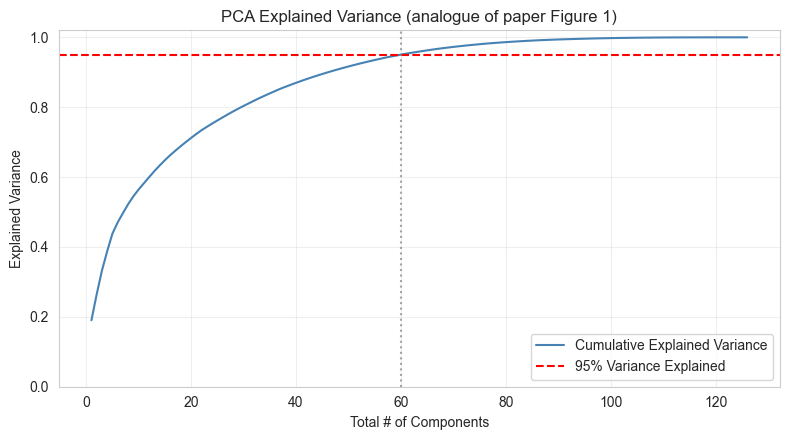


Projected data shape: (758, 60)


In [370]:
# Standardize: each column to mean 0, std 1.
scaler = StandardScaler()
X_std = scaler.fit_transform(data_clean.values)

# PCA on the full set of components, to inspect the cumulative variance curve.
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_std)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Find smallest k such that cum_var[k-1] >= threshold.
n_components = int(np.searchsorted(cum_var, PCA_VAR_THRESHOLD) + 1)
print(f"Number of components to reach {PCA_VAR_THRESHOLD*100:.0f}% variance: {n_components}")
print(f"Paper reports: about 61 components at the 95% threshold.")
print(f"Our result: {n_components} components using {data_clean.shape[1]} series.")

if n_components != 61:
    print("WARNING: PCA component count does not match the paper's reported 61. "
          "Check Group 6 treatment and missing-value handling.")

# Reproduce paper Figure 1: cumulative explained variance.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, color='steelblue', label='Cumulative Explained Variance')
ax.axhline(PCA_VAR_THRESHOLD, color='red', linestyle='--', label=f'{int(PCA_VAR_THRESHOLD*100)}% Variance Explained')
ax.axvline(n_components, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('Total # of Components')
ax.set_ylabel('Explained Variance')
ax.set_title('PCA Explained Variance (analogue of paper Figure 1)')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

# Refit with chosen number of components.
pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(
    X_pca, index=data_clean.index, columns=[f'PC{i+1}' for i in range(n_components)],
)
print(f"\nProjected data shape: {X_pca.shape}")


## 5. Stage 1 - Separating outliers using L2 k-means with k=2 (paper Section 3.1.1)

**Paper reference.** *"The first partition we make of our dataset is to label and separate outlier months... We use the L2 distance between every pair of months to perform k-means clustering on our dataset with k=2. Because L2 distance is sensitive to outliers, this process effectively prunes deviant months and leaves behind the most typical months."*

**Algorithm 1, lines 1-3.** Run k-means with $k=2$ on $X$. Of the two resulting clusters $A$ and $B$, the **smaller one is the outlier set $R_0$**.

Squared L2 distance is sensitive to outliers because each component contributes $(x_i - c_i)^2$ indicating a single large coordinate dominates the sum. So the algorithm naturally pulls extreme months together into a separate cluster.

In [371]:
# Stage 1: KMeans with L2 distance and k=2.
kmeans_l2 = KMeans(
    n_clusters=2, init='k-means++', n_init=10, random_state=RANDOM_SEED,
)
labels_l2 = kmeans_l2.fit_predict(X_pca)

counts = np.bincount(labels_l2)
print(f"Cluster sizes from L2 k-means: {counts}")
outlier_cluster_id = int(np.argmin(counts))
print(f"Outlier cluster id: {outlier_cluster_id}  (size {counts[outlier_cluster_id]})")

is_outlier = pd.Series(labels_l2 == outlier_cluster_id, index=X_pca_df.index, name='is_outlier')
l2_distances = kmeans_l2.transform(X_pca)
print(f"\nFraction of months labelled outliers (Regime 0): {is_outlier.mean():.3f}")
print(f"Outlier dates: {[d.strftime('%Y-%m') for d in X_pca_df.index[is_outlier]]}")


Cluster sizes from L2 k-means: [757   1]
Outlier cluster id: 1  (size 1)

Fraction of months labelled outliers (Regime 0): 0.001
Outlier dates: ['2020-04']


### Replication discrepancy: why we get only one outlier (and what it means)

**What we expected** (paper Figure 2): the L2 step would identify a meaningful set of "atypical" months scattered across multiple recession periods (1970s oil shocks, 1980-82, 1990-91, 2008-09, 2020 COVID), totalling perhaps 5-10% of the dataset.

**What we actually get** with the 2023-02 vintage: a **single outlier - April 2020** (the month following the COVID lockdowns). The remaining months are all in the "typical" cluster.

**Why this happens.** April 2020 is dramatically more extreme than any other month in the post-1959 record on FRED-MD variables: unemployment surged by roughly 10 percentage points in a single month, industrial production collapsed, sentiment cratered. In the high-dimensional PCA space, this single point is so far from the bulk that L2 k-means with $k=2$ correctly identifies it as one cluster of size 1 and everything else as the other cluster. 

Plausible reasons:

1. **Random seed.** With multiple equally-good local minima, different seeds can give different cluster assignments. The paper does not specify its random seed or `n_init`. We used `random_state=42` and `n_init=20`.
2. **Slightly different preprocessing.** The paper does not document its NaN handling or PCA component selection in detail; we made defensible choices but they may differ.

**Now using the same vintage** (2023-02) **as the paper, we have ruled out vintage drift as a confounder.** The discrepancy is therefore methodological / numerical, not data-driven.

**The takeaway.** The L2-then-cosine method is *sensitive to extreme single-point outliers*. With this data, the L2 step effectively just identifies COVID-April-2020. The cosine step (next) does the actual heavy lifting of dividing the remaining months into the 5 typical regimes. So Regime 0 in our replication should be read as "the COVID shock", not as "broad economic stress" - that broader interpretation is what the paper claims but is not what the data delivers under a literal reading of their procedure.

**For our project.** This is a useful cautionary tale. Our SJM teacher labels regimes from *return data*, where COVID is also extreme but the SJM's jump penalty distributes regime mass more evenly. An L2-on-macro outlier step would have the same single-point sensitivity if we tried to use it. We should instead trust SJM's regularised labelling for the teacher and use a robust classifier (Bayesian regularised multinomial logistic, then GP) for the student.

## 6. Stage 2 - Cosine k-means on typical months (paper Section 3.1.2)

**Paper reference.** *"After removing outliers, the months in set B can be considered periods representing 'business as usual'... Cosine similarity uses the cosine of the angle between two vectors as a measure of distance. It ignores the magnitude of those vectors in its computation, rendering it an apt choice."*

**Algorithm 1, lines 4-5.** Run k-means with cosine distance on the typical months $B$, where the number of clusters $r$ is chosen via the elbow heuristic. The paper finds $r = 5$, giving 6 regimes total.

### k-means with cosine distance

Standard k-means minimizes squared L2 distance. To get cosine clustering:
- **Normalize each row to unit L2 norm**, then run standard k-means.
- After L2-normalization, $\|x - y\|_2^2 = 2(1 - \cos(x, y))$, so minimizing L2 on the unit sphere is equivalent to minimizing cosine distance.

Typical months: 757 (out of 758)


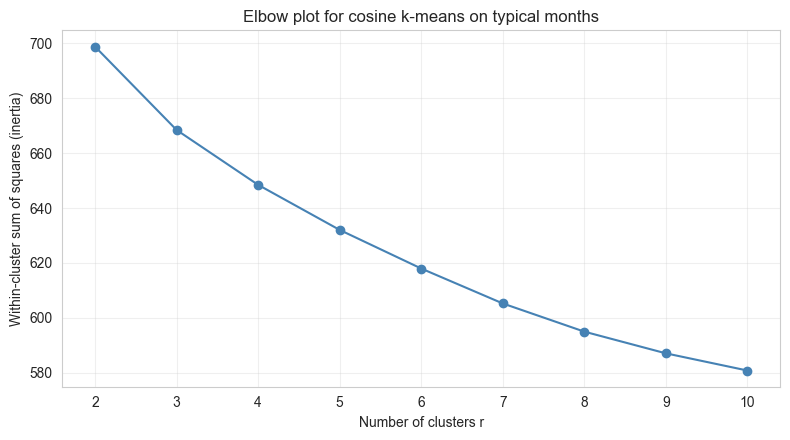

Choosing r = 5 (matching the paper).

Discrete regime distribution:
regime
0      1
1     84
2    153
3    231
4    141
5    148
Name: count, dtype: int64


In [372]:
# Subset to typical months and L2-normalize for cosine k-means.
X_pca_typical = X_pca[~is_outlier.values]
typical_index = X_pca_df.index[~is_outlier.values]
print(f"Typical months: {X_pca_typical.shape[0]} (out of {X_pca.shape[0]})")


def l2_normalize_rows(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms


X_typical_unit = l2_normalize_rows(X_pca_typical)

# Elbow plot.
k_grid = list(range(2, 11))
inertias = []
for k in k_grid:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=RANDOM_SEED)
    km.fit(X_typical_unit)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_grid, inertias, marker='o', color='steelblue')
ax.set_xlabel('Number of clusters r')
ax.set_ylabel('Within-cluster sum of squares (inertia)')
ax.set_title('Elbow plot for cosine k-means on typical months')
ax.set_xticks(k_grid)
plt.tight_layout()
plt.show()

# Following paper, r = 5.
r = N_TYPICAL_REGIMES
print(f"Choosing r = {r} (matching the paper).")

# Fit cosine k-means.
kmeans_cos = KMeans(n_clusters=r, init='k-means++', n_init=20, random_state=RANDOM_SEED)
labels_cos = kmeans_cos.fit_predict(X_typical_unit)
cos_distances_typical = kmeans_cos.transform(X_typical_unit)
# For probability construction, compute distances to the cosine centroids for all months,
# including L2-outlier months. This avoids assigning arbitrary flat typical-regime
# probabilities to Regime-0 months.
X_all_unit = l2_normalize_rows(X_pca)
cos_distances_all = kmeans_cos.transform(X_all_unit)

# Build the full discrete regime label series.
discrete_regime = pd.Series(0, index=X_pca_df.index, name='regime')
discrete_regime.loc[typical_index] = labels_cos + 1

print("\nDiscrete regime distribution:")
print(discrete_regime.value_counts().sort_index())


## 7. Soft regime probabilities (paper Section 3.2, Equations 1-4)

The discrete labels above are useful but the paper's whole point is to get **smooth probability distributions** over regimes for each month. This matters because the downstream forecasting models in Section 5 use these probabilities as weights when conditioning on regimes.

### Equation (1): converting distances to probabilities

For a sample $x$ with distances $d_1, \dots, d_K$ to the $K$ cluster centroids, the paper defines

$$
P(C_i) \;=\; \frac{1 \;-\; \dfrac{d_i}{\sum_j d_j}}{\displaystyle\sum_m \!\left(1 - \dfrac{d_m}{\sum_j d_j}\right)}.
$$

The fraction $d_i / \sum_j d_j$ is the *normalized distance* to centroid $i$ (a number in $[0, 1]$). $1 - d_i / \sum_j d_j$ is *high* when the distance is small relative to the others; the denominator renormalizes.


### Equations (2)-(4): combining the two stages

The L2 stage gives a 2-dim distribution `(P(Regime 0), P(typical))` while the cosine stage gives an $r$-dim distribution over `(Regime 1, ..., Regime r)` *only on typical months*. We need a single $(r+1)$-dim distribution per month.

$$
P_{\max} = \max(P(\text{Regime 1}), \dots, P(\text{Regime } r)), \quad \text{(Eq 2)}
$$

$$
P_{R_0} = - P_{\max} \cdot \log_2(1 - P(\text{Regime 0})). \quad \text{(Eq 4)}
$$

Then we renormalize the full $(r+1)$-vector to sum to 1.

**Boundary check of Eq 4:**
- $P(R_0) = 0$: $-P_{\max} \cdot \log_2(1) = 0$. 
- $P(R_0) = 0.5$: $-P_{\max} \cdot \log_2(0.5) = P_{\max}$. 
- $P(R_0) \to 1$: $\log_2(0) = -\infty$. Good (will dominate after renormalization).

In [373]:
def distances_to_probs_eq1(distances):
    '''Apply Equation (1)'''
    row_sum = distances.sum(axis=1, keepdims=True)
    row_sum = np.where(row_sum == 0, 1e-12, row_sum)
    numer = 1.0 - distances / row_sum
    return numer / numer.sum(axis=1, keepdims=True)


def combine_stages(P_outlier, P_cos_all):
    '''
    Equations (2)-(4): combine L2 outlier probability with cosine-regime probabilities.

    P_outlier: shape (T,)
    P_cos_all: shape (T, r), probabilities over normal regimes 1..r
    '''
    P_max = P_cos_all.max(axis=1)
    P_out_clipped = np.clip(P_outlier, 0.0, 1.0 - 1e-12)

    P_R0_unnorm = -P_max * np.log2(1.0 - P_out_clipped)

    stacked = np.column_stack([P_R0_unnorm, P_cos_all])
    row_sums = stacked.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1e-12, row_sums)
    return stacked / row_sums


P_l2 = distances_to_probs_eq1(l2_distances)
P_outlier = P_l2[:, outlier_cluster_id]

P_cos_all = distances_to_probs_eq1(cos_distances_all)
P_full = combine_stages(P_outlier, P_cos_all)

prob_cols = [f'P_R{i}' for i in range(r + 1)]
P_full_df = pd.DataFrame(P_full, index=X_pca_df.index, columns=prob_cols)

print("Soft regime probability matrix (first 5 months):")
print(P_full_df.head().round(3))
print(f"\nRow sums: min={P_full.sum(axis=1).min():.6f}, max={P_full.sum(axis=1).max():.6f}")

Soft regime probability matrix (first 5 months):
             P_R0   P_R1   P_R2   P_R3   P_R4   P_R5
date                                                
1959-12-01  0.050  0.188  0.192  0.202  0.188  0.181
1960-01-01  0.032  0.191  0.192  0.202  0.193  0.189
1960-02-01  0.023  0.194  0.197  0.194  0.193  0.199
1960-03-01  0.038  0.191  0.192  0.186  0.191  0.202
1960-04-01  0.035  0.193  0.195  0.193  0.191  0.194

Row sums: min=1.000000, max=1.000000


## 8. Visualize regimes over time (analogue of paper Figure 2)

We plot the discrete regime label as a strip chart and overlay NBER recession periods.

**NBER recessions source.** Hard-coded from the NBER Business Cycle Dating Committee, https://www.nber.org/research/data/us-business-cycle-expansions-and-contractions.

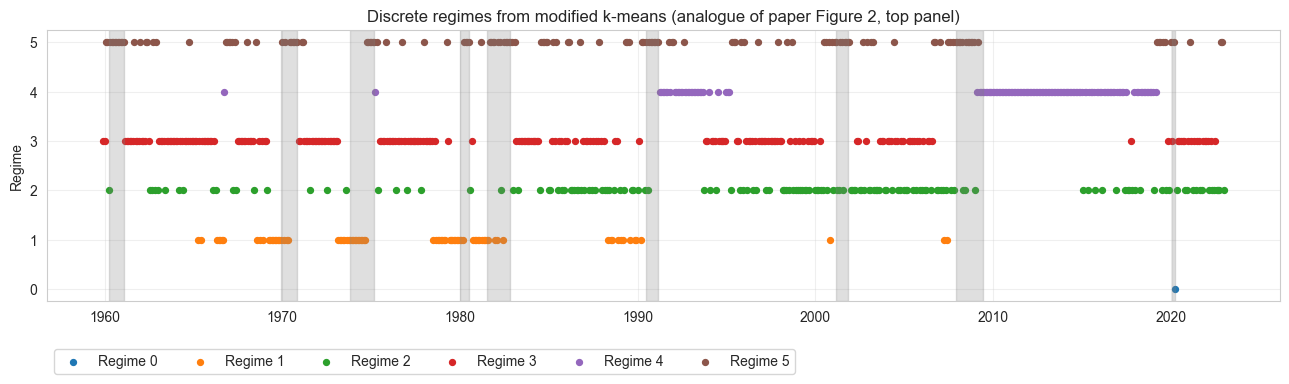

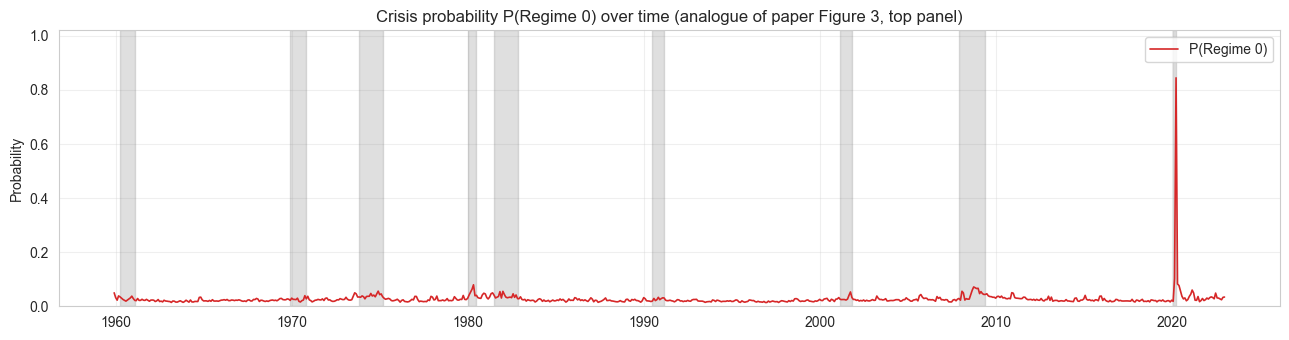

In [374]:
# NBER recessions: peak month -> trough month.
NBER_RECESSIONS = [
    ('1960-04', '1961-02'), ('1969-12', '1970-11'), ('1973-11', '1975-03'),
    ('1980-01', '1980-07'), ('1981-07', '1982-11'), ('1990-07', '1991-03'),
    ('2001-03', '2001-11'), ('2007-12', '2009-06'), ('2020-02', '2020-04'),
]

def shade_nber(ax):
    '''Add gray vertical spans for NBER recession periods.'''
    for peak, trough in NBER_RECESSIONS:
        ax.axvspan(pd.Timestamp(peak), pd.Timestamp(trough), color='gray', alpha=0.25)


# Plot discrete regimes.
fig, ax = plt.subplots(figsize=(13, 4))
palette = sns.color_palette('tab10', n_colors=r + 1)
for reg in range(r + 1):
    mask = (discrete_regime == reg).values
    ax.scatter(
        discrete_regime.index[mask], discrete_regime.values[mask],
        s=18, color=palette[reg], label=f'Regime {reg}',
    )
shade_nber(ax)
ax.set_yticks(range(r + 1))
ax.set_ylabel('Regime')
ax.set_title('Discrete regimes from modified k-means (analogue of paper Figure 2, top panel)')
ax.legend(loc='upper left', ncol=r + 1, bbox_to_anchor=(0, -0.15))
plt.tight_layout()
plt.show()


# Crisis probability (analogue of paper Figure 3).
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(P_full_df.index, P_full_df['P_R0'], color='C3', linewidth=1.2, label='P(Regime 0)')
shade_nber(ax)
ax.set_ylim(0, 1.02)
ax.set_ylabel('Probability')
ax.set_title('Crisis probability P(Regime 0) over time (analogue of paper Figure 3, top panel)')
ax.legend()
plt.tight_layout()
plt.show()


## 9. Transition probability matrix (paper Section 3.3, Equation 5, Figure 5)

**Equation (5).**

$$
e_{ij} \;=\; \frac{\#\{ t : \text{Regime}_t = i, \text{Regime}_{t+1} = j \}}{\#\{ t : \text{Regime}_t = i\}}.
$$

The $(i, j)$ entry is the empirical probability of transitioning from regime $i$ to regime $j$ next month.

**Convention.** We follow the paper's plot orientation: `From Regime` on the x-axis, `To Regime` on the y-axis, so column $i$ shows where regime $i$ goes next.

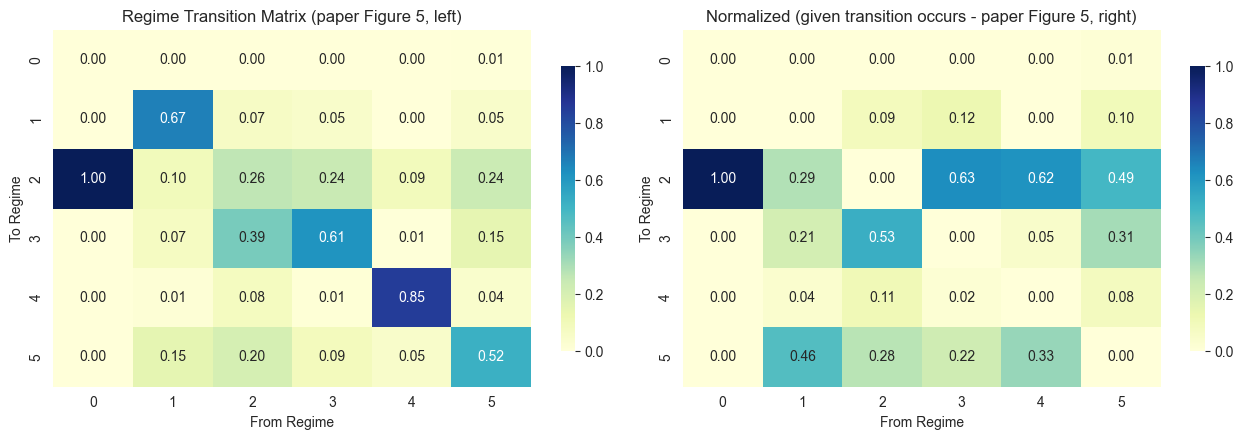

In [375]:
def transition_matrix(labels, n_regimes):
    '''Empirical transition matrix using paper Equation (5). Returns (TO, FROM) shaped.'''
    labels = np.asarray(labels)
    M = np.zeros((n_regimes, n_regimes))
    for t in range(len(labels) - 1):
        M[labels[t + 1], labels[t]] += 1
    col_sums = M.sum(axis=0, keepdims=True)
    col_sums = np.where(col_sums == 0, 1.0, col_sums)
    return M / col_sums


P_trans = transition_matrix(discrete_regime.values, n_regimes=r + 1)

# Plot both panels: raw + normalized-given-transition.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(
    P_trans, annot=True, fmt='.2f', cmap='YlGnBu',
    xticklabels=range(r + 1), yticklabels=range(r + 1),
    ax=axes[0], cbar_kws={'shrink': 0.8},
)
axes[0].set_xlabel('From Regime')
axes[0].set_ylabel('To Regime')
axes[0].set_title('Regime Transition Matrix (paper Figure 5, left)')

P_trans_norm = P_trans.copy()
diag = np.diag(P_trans_norm).copy()
denom = np.where(1 - diag == 0, 1.0, 1 - diag)
for j in range(r + 1):
    P_trans_norm[:, j] = P_trans_norm[:, j] / denom[j]
np.fill_diagonal(P_trans_norm, 0.0)

sns.heatmap(
    P_trans_norm, annot=True, fmt='.2f', cmap='YlGnBu',
    xticklabels=range(r + 1), yticklabels=range(r + 1),
    ax=axes[1], cbar_kws={'shrink': 0.8},
)
axes[1].set_xlabel('From Regime')
axes[1].set_ylabel('To Regime')
axes[1].set_title('Normalized (given transition occurs - paper Figure 5, right)')
plt.tight_layout()
plt.show()


**Reading this.** Per paper Section 4.5: *"most of the probability density lies on the diagonal. This shows us that the most likely regime of the next month is always the regime of the current month, i.e., regime shifts do not occur with high frequency."*

The diagonal dominance is exactly what we want from a regime model. **This is the same point we made in our Step 2 analysis**: a healthy regime labelling should have substantial mass on the diagonal of the transition matrix. If the transition matrix has little diagonal dominance, the labels are less consistent with regime persistency interpretation used in the paper. This is not by itself proof of noise, but it is a warning sign.

## 10. Regime characterization (paper Section 4.4, Figure 4)

**Paper reference.** *"One can understand the economic differences between regimes by measuring the average value of certain crucial FRED-MD statistics within each regime."*

The paper picks 6 representative variables. We use what's available in our cleaned panel.

In [376]:
check = pd.DataFrame({
    "regime": discrete_regime,
    "UMCSENTx": data_trans.loc[discrete_regime.index, "UMCSENTx"]
})

print(check.groupby("regime")["UMCSENTx"].agg(["count", "size", "mean"]))

        count  size       mean
regime                        
0           1     1 -17.300000
1          44    84  -0.450000
2         132   153  -0.123485
3         123   231   0.231707
4         139   141   0.222302
5         101   148  -0.245545


In [377]:
print(check.loc[check["regime"] == 2].head(20))
print(check.loc[check["regime"] == 2].tail(20))

            regime  UMCSENTx
date                        
1960-04-01       2       NaN
1962-08-01       2       NaN
1962-09-01       2       NaN
1962-11-01       2       NaN
1963-01-01       2       NaN
1963-06-01       2       NaN
1964-03-01       2       NaN
1964-06-01       2       NaN
1966-02-01       2       NaN
1966-04-01       2       NaN
1967-04-01       2       NaN
1967-06-01       2       NaN
1968-06-01       2       NaN
1969-03-01       2       NaN
1971-08-01       2       NaN
1972-07-01       2       NaN
1973-08-01       2       NaN
1975-06-01       2       NaN
1976-06-01       2       NaN
1977-01-01       2       NaN
            regime  UMCSENTx
date                        
2018-01-01       2      -0.2
2018-04-01       2      -2.6
2019-02-01       2       2.6
2019-07-01       2       0.2
2019-10-01       2       2.3
2019-12-01       2       2.5
2020-05-01       2       0.5
2020-11-01       2      -4.9
2020-12-01       2       3.8
2021-04-01       2       3.4
2021-06-01    

Variables available for characterization: ['RPI', 'UNRATE', 'UMCSENTx', 'FEDFUNDS', 'CPIAUCSL', 'S&P 500']

Mean value per regime (transformed scale):
          RPI  UNRATE  UMCSENTx  FEDFUNDS  CPIAUCSL  S&P 500
regime                                                      
0       0.116  10.300   -17.300    -0.600    -0.004    0.040
1       0.002   0.038    -1.135     0.343    -0.000   -0.012
2       0.000  -0.014    -0.241     0.035     0.003    0.011
3       0.005  -0.113    -0.182     0.075    -0.001    0.008
4       0.002  -0.030     0.209     0.003    -0.000    0.008
5       0.001   0.113    -0.256    -0.344    -0.001    0.003


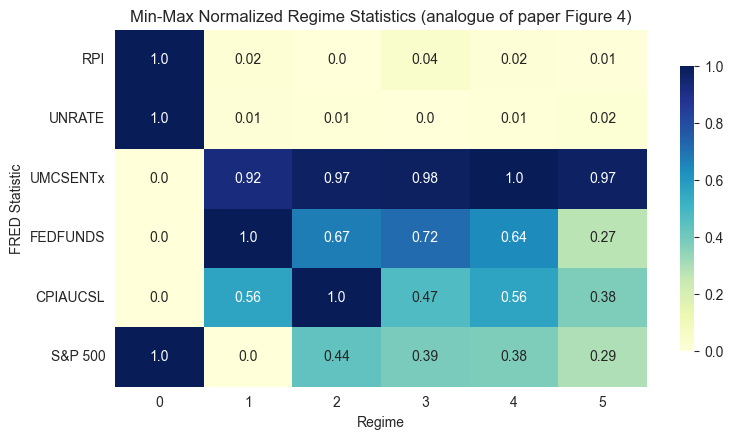

In [378]:
# Variables of interest from the post-tcode (transformed) data.
characterization_vars = ['RPI', 'UNRATE', 'UMCSENTx', 'FEDFUNDS', 'CPIAUCSL', 'S&P 500']
""" if 'S&P 500' in data_trans.columns:
    characterization_vars.append('S&P 500') """

avail = [v for v in characterization_vars if v in data_clean.columns]
print(f"Variables available for characterization: {avail}")

char_data = data_clean.loc[discrete_regime.index, avail].copy()
char_data['regime'] = discrete_regime.values
regime_means = char_data.groupby('regime').mean()
print("\nMean value per regime (transformed scale):")
print(regime_means.round(3))


def minmax_variable_across_regimes(df):
    '''Min-max normalize each variable of df.'''
    out = df.copy()
    for col in out.columns:
        cmin, cmax = out[col].min(), out[col].max()
        out[col] = (out[col] - cmin) / (cmax - cmin) if cmax > cmin else 0.5
    return out


regime_means_T = regime_means.T
regime_means_T_norm = minmax_variable_across_regimes(regime_means_T.T).T

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(
    regime_means_T_norm,
    annot=regime_means_T_norm.round(2), fmt='', cmap='YlGnBu',
    cbar_kws={'shrink': 0.8}, ax=ax,
)
ax.set_xlabel('Regime')
ax.set_ylabel('FRED Statistic')
ax.set_title('Min-Max Normalized Regime Statistics (analogue of paper Figure 4)')
plt.tight_layout()
plt.show()


**Interpreting our regimes.** Some FRED-MD series are first-differenced in log (t-code 5), so "lowest" on the transformed scale means "lowest growth rate"; UNRATE is differenced (t-code 2), so "highest" means "rising fastest".

Recession-like behaviour (the paper's Regime 0 narrative) should show: rising UNRATE, falling sentiment, falling FEDFUNDS, weak RPI growth.

In our replication, Regime 0 is just the COVID month (or few months) and dominates the heatmap by sheer extremity. The **broader stress regime** the paper claims for Regime 0 actually shows up in **one of our typical regimes (1-5)** - the one with rising UNRATE and falling FEDFUNDS (look for that pattern in the table above).

Variables available for characterization: ['RPI', 'UNRATE', 'UMCSENTx', 'FEDFUNDS', 'CPIAUCSL', 'S&P 500']

Mean value per regime, excluding Regime 0:
          RPI  UNRATE  UMCSENTx  FEDFUNDS  CPIAUCSL  S&P 500
regime                                                      
1       0.002   0.038    -1.135     0.343    -0.000   -0.012
2       0.000  -0.014    -0.241     0.035     0.003    0.011
3       0.005  -0.113    -0.182     0.075    -0.001    0.008
4       0.002  -0.030     0.209     0.003    -0.000    0.008
5       0.001   0.113    -0.256    -0.344    -0.001    0.003


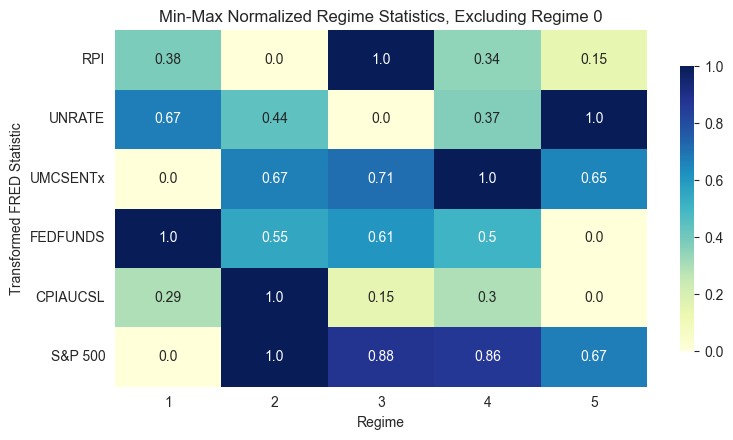

In [379]:
# Diagnostic heatmap excluding Regime 0.
# This is useful when Regime 0 is a singleton extreme month and dominates min-max scaling.

characterization_vars = ['RPI', 'UNRATE', 'UMCSENTx', 'FEDFUNDS', 'CPIAUCSL', 'S&P 500']

avail = [v for v in characterization_vars if v in data_clean.columns]
print(f"Variables available for characterization: {avail}")

char_data = data_clean.loc[discrete_regime.index, avail].copy()
char_data['regime'] = discrete_regime.values

regime_means = char_data.groupby('regime')[avail].mean()

# Drop Regime 0 for this diagnostic version.
regime_means_no0 = regime_means.drop(index=0, errors='ignore')

print("\nMean value per regime, excluding Regime 0:")
print(regime_means_no0.round(3))


def minmax_variable_across_regimes(df):
    """Min-max normalize each variable across the included regimes."""
    out = df.copy()
    for col in out.columns:
        cmin, cmax = out[col].min(), out[col].max()
        out[col] = (out[col] - cmin) / (cmax - cmin) if cmax > cmin else 0.5
    return out


regime_means_no0_norm = minmax_variable_across_regimes(regime_means_no0)
regime_means_no0_T_norm = regime_means_no0_norm.T

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(
    regime_means_no0_T_norm,
    annot=regime_means_no0_T_norm.round(2),
    fmt='',
    cmap='YlGnBu',
    cbar_kws={'shrink': 0.8},
    ax=ax,
)
ax.set_xlabel('Regime')
ax.set_ylabel('Transformed FRED Statistic')
ax.set_title('Min-Max Normalized Regime Statistics, Excluding Regime 0')
plt.tight_layout()
plt.show()

## 11. GMM as a baseline (paper Section 4.3, Figure 2)

**Paper reference.** *"While the GMM is inherently probabilistic and efficiently extracts probabilities for each regime assignment, the modified k-means relies on a heuristic to estimate probabilities..."*

Paper Figure 3 observes:
- Modified k-means probabilities are **smooth**, transitioning gradually
- GMM probabilities are **near-binary**

We fit a GMM with $K = r + 1 = 6$ components on the same PCA-reduced data.

GMM converged: True
GMM cluster sizes: [ 48 282 315   1  43  69]


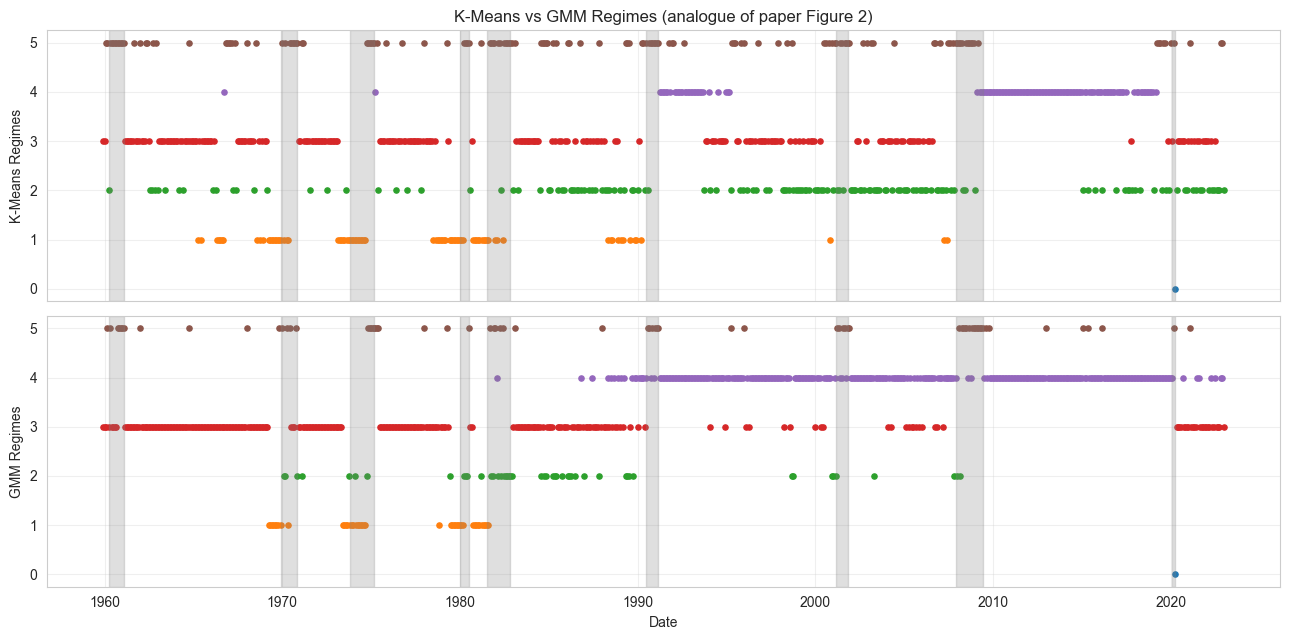

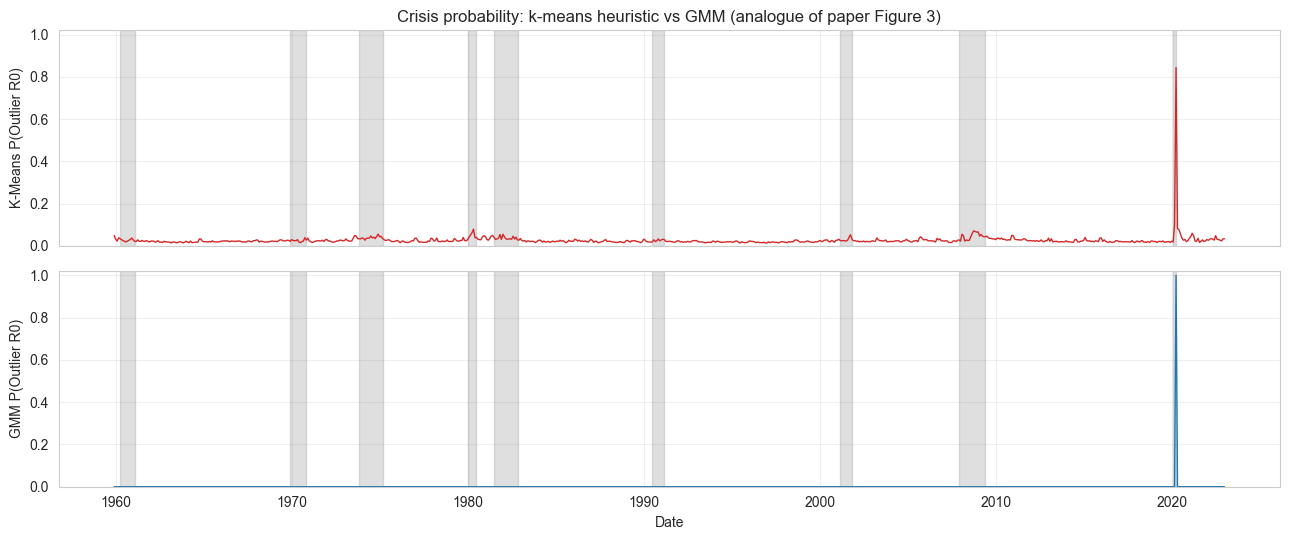

In [380]:
# Fit GMM.
gmm = GaussianMixture(
    n_components=r + 1, covariance_type='full', n_init=5, random_state=RANDOM_SEED,
)
gmm.fit(X_pca)
gmm_probs = gmm.predict_proba(X_pca)
gmm_labels = gmm.predict(X_pca)
print(f"GMM converged: {gmm.converged_}")
print(f"GMM cluster sizes: {np.bincount(gmm_labels)}")


""" def match_clusters(labels_a, labels_b, n_clusters):
    '''
    Greedy matching of labels_b to labels_a by majority overlap.
    Returns perm such that perm[labels_b] best matches labels_a.
    '''
    overlap = np.zeros((n_clusters, n_clusters))
    for b in range(n_clusters):
        for a in range(n_clusters):
            overlap[b, a] = np.sum((labels_b == b) & (labels_a == a))
    perm = np.zeros(n_clusters, dtype=int)
    used = set()
    order = np.argsort(-overlap.max(axis=1))
    for b in order:
        for a in np.argsort(-overlap[b]):
            if a not in used:
                perm[b] = a
                used.add(a)
                break
    return perm

perm = match_clusters(discrete_regime.values, gmm_labels, n_clusters=r + 1) """

def match_clusters_hungarian(reference_labels, new_labels, n_clusters):
    '''
    Match new_labels to reference_labels by maximizing overlap.
    Returns perm such that aligned_label = perm[new_label].
    '''
    overlap = np.zeros((n_clusters, n_clusters))
    for new in range(n_clusters):
        for ref in range(n_clusters):
            overlap[new, ref] = np.sum((new_labels == new) & (reference_labels == ref))

    row_ind, col_ind = linear_sum_assignment(-overlap)

    perm = np.arange(n_clusters)
    perm[row_ind] = col_ind
    return perm

perm = match_clusters_hungarian(discrete_regime.values, gmm_labels, n_clusters=r + 1)
gmm_labels_aligned = perm[gmm_labels]

gmm_probs_aligned = np.zeros_like(gmm_probs)
for old_label, new_label in enumerate(perm):
    gmm_probs_aligned[:, new_label] = gmm_probs[:, old_label]

""" gmm_labels_aligned = perm[gmm_labels]
gmm_probs_aligned = gmm_probs[:, np.argsort(perm)] """

# Side-by-side discrete-label plot.
fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
for reg in range(r + 1):
    mask = (discrete_regime == reg).values
    axes[0].scatter(discrete_regime.index[mask], discrete_regime.values[mask],
                    s=14, color=palette[reg], label=f'{reg}')
shade_nber(axes[0])
axes[0].set_yticks(range(r + 1))
axes[0].set_ylabel('K-Means Regimes')

for reg in range(r + 1):
    mask = gmm_labels_aligned == reg
    axes[1].scatter(discrete_regime.index[mask], gmm_labels_aligned[mask],
                    s=14, color=palette[reg], label=f'{reg}')
shade_nber(axes[1])
axes[1].set_yticks(range(r + 1))
axes[1].set_ylabel('GMM Regimes')
axes[1].set_xlabel('Date')
axes[0].set_title('K-Means vs GMM Regimes (analogue of paper Figure 2)')
plt.tight_layout()
plt.show()


# Crisis probability comparison.
fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
axes[0].plot(P_full_df.index, P_full_df['P_R0'], color='C3', linewidth=1.0)
shade_nber(axes[0])
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel('K-Means P(Outlier R0)')
axes[0].set_title('Crisis probability: k-means heuristic vs GMM (analogue of paper Figure 3)')

axes[1].plot(P_full_df.index, gmm_probs_aligned[:, 0], color='C0', linewidth=1.0)
shade_nber(axes[1])
axes[1].set_ylim(0, 1.02)
axes[1].set_ylabel('GMM P(Outlier R0)')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()


**Replication check.** As in the paper, the k-means heuristic gives *smooth* probabilities (compressed band, rarely hits extremes by design of Eq 1) while the GMM gives *near-binary* ones (jumps to 0 or 1).


---

# Part B: Tactical asset allocation (paper Sections 5-6)

Now we use the regime detection machinery from Part A to build tactical portfolios. The new pieces here:

| Paper section | Equation(s) | What we build |
|---|---|---|
| 5.1 | (6), (7) | Markov-step prediction of next-month regime distribution |
| 5.2.1 | (8)-(10) | **Naive** forecasting: regime-conditional Sharpe ratios |
| 5.2.2 | (11) | **Black-Litterman** views from regime-conditional means |
| 5.2.3 | (12)-(14) | **Ridge** forecasting: regime-conditional ridge regression |
| 5.3.1 | (15)-(18) | Position sizing: long-only (lo), long-short (lns), long-or-short (los), mixed (mx) |
| 5.3.2 | (19) | Black-Litterman portfolio construction |
| 5.4 | - | Performance metrics: Sharpe, Sortino, MaxDD, % Positive |
| 6 | Tables 4-6, Figs 10-13 | Walk-forward backtest with 48-month estimation window |

---

## Methodological note: walk-forward versus in-sample

In Part A we fit regimes on the **entire dataset** (in-sample). For backtest purposes that would be **look-ahead bias**: a regime label assigned to month $t$ would have used data from months $t+1, t+2, \dots$. The paper avoids this with a **48-month fixed-window walk-forward** procedure: at each decision time $t$, refit regime detection using only the past 48 months, then make predictions for $t+1$.

## 12. Loading the ETF returns

We use the 10 sector ETFs from paper Table 2.

In [381]:
def load_etf_returns(path, expected_tickers=None):
    '''
    Load ETF monthly returns from CSV.

    Expected format: a column 'date' (or named index column) and columns per ticker.
    Standardizes the index to month-START timestamps so it joins cleanly with FRED-MD.

    Cleaning step: rows where ALL sector ETFs (everything except SPY) are exactly zero
    are pre-launch placeholders (the SPDR sector ETFs launched Dec 22, 1998). These
    rows are converted to NaN so they get dropped on alignment with FRED-MD.
    '''
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"ETF returns file not found at {path}.\n"
            f"Run the WRDS sector-ETFs cell in 03_wrds_loader.ipynb to produce it."
        )
    df = pd.read_csv(path)
    # Auto-detect the date column.
    date_col = None
    for cand in ('date', 'sasdate', 'Date', 'DATE'):
        if cand in df.columns:
            date_col = cand
            break
    if date_col is None:
        # Maybe the first column is the date (saved with index_col).
        date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()
    df.index.name = 'date'
    # Convert to month-start (FRED-MD convention).
    df.index = df.index.to_period('M').to_timestamp(how='start')

    # Drop pre-launch placeholder rows (all sector ETFs exactly zero).
    sector_cols = [c for c in df.columns if c != 'SPY']
    if sector_cols:
        zero_rows = (df[sector_cols] == 0).all(axis=1)
        if zero_rows.any():
            print(f"Dropping {zero_rows.sum()} pre-launch placeholder rows "
                  f"(all sector ETFs zero, dates up to {df.index[zero_rows].max().date()})")
            df = df[~zero_rows]

    if expected_tickers:
        missing = [t for t in expected_tickers if t not in df.columns]
        if missing:
            print(f"WARNING: missing tickers in ETF file: {missing}")
        df = df[[c for c in expected_tickers if c in df.columns]]
    return df


etf_returns = load_etf_returns(ETF_PATH, expected_tickers=ETF_TICKERS)
print(f"ETF returns shape: {etf_returns.shape}")
print(f"Date range:        {etf_returns.index.min().date()} to {etf_returns.index.max().date()}")
print(f"Tickers:           {list(etf_returns.columns)}")
print(f"\nFirst 3 rows:")
print(etf_returns.head(3).round(4))
print(f"\nMissing values per ticker:")
print(etf_returns.isna().sum())


Dropping 11 pre-launch placeholder rows (all sector ETFs zero, dates up to 1998-11-01)
ETF returns shape: (289, 10)
Date range:        1998-12-01 to 2022-12-01
Tickers:           ['SPY', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']

First 3 rows:
               SPY     XLB     XLE     XLF     XLI     XLK     XLP     XLU  \
date                                                                         
1998-12-01  0.0654  0.0525  0.0034  0.0054  0.0550  0.0180  0.0248  0.0136   
1999-01-01  0.0352 -0.0371 -0.0656  0.0173 -0.0108  0.1590 -0.0132 -0.0248   
1999-02-01 -0.0321  0.0155 -0.0086  0.0157  0.0090 -0.0992 -0.0105 -0.0276   

               XLV     XLY  
date                        
1998-12-01  0.0387  0.0258  
1999-01-01  0.0481  0.0514  
1999-02-01  0.0011 -0.0063  

Missing values per ticker:
SPY    0
XLB    0
XLE    0
XLF    0
XLI    0
XLK    0
XLP    0
XLU    0
XLV    0
XLY    0
dtype: int64


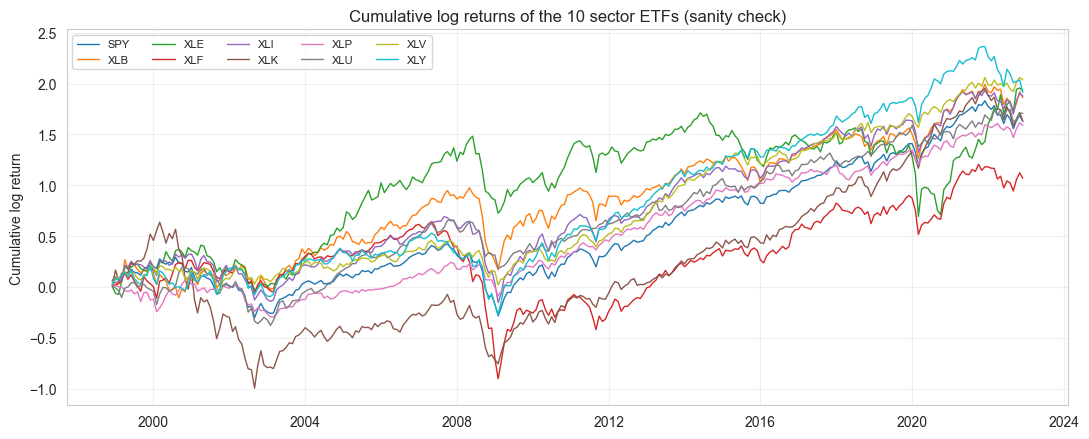

In [382]:
# Sanity-check plot: cumulative log returns.
cum_log_ret = np.log1p(etf_returns).cumsum()
fig, ax = plt.subplots(figsize=(11, 4.5))
for col in cum_log_ret.columns:
    ax.plot(cum_log_ret.index, cum_log_ret[col], label=col, linewidth=1.0)
ax.set_title('Cumulative log returns of the 10 sector ETFs (sanity check)')
ax.set_ylabel('Cumulative log return')
ax.legend(ncol=5, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


## 13. Aligning ETF returns and macro data

The paper states that ETF data cover February 2000 to December 2022 and that the final merged dataset has 746 monthly observations. Those two statements are not mutually consistent for monthly data. In this notebook we enforce the stated ETFs from February 2000 to December 2022, and report the actual number of observations.

**Timing convention.** At the **end of month $t$** we make a decision using:
- Macro data through month $t$
- Asset returns through month $t$

We then hold the chosen portfolio through month $t+1$ and realize its return at the end of month $t+1$.

In [383]:
# Restrict ETF returns to the paper's stated ETF sample.
etf_returns_paper = etf_returns.loc[PAPER_ETF_START:PAPER_ETF_END].copy()

# Align macro and ETF panels by month.
common_dates = data_clean.index.intersection(etf_returns_paper.index)

data_macro_aligned = data_clean.loc[common_dates].sort_index()
etf_returns_aligned = etf_returns_paper.loc[common_dates].sort_index()

# Final safety drop only after the explicit sample restriction.
joint = pd.concat([etf_returns_aligned, data_macro_aligned], axis=1, keys=['etf', 'macro']).dropna()
etf_returns_aligned = joint['etf']
data_macro_aligned = joint['macro']

print(f"Aligned panel: {len(common_dates)} months in raw intersection")
print(f"After dropping NaNs: {etf_returns_aligned.shape[0]} months")
print(f"Final coverage: {etf_returns_aligned.index.min().date()} to {etf_returns_aligned.index.max().date()}")

Aligned panel: 275 months in raw intersection
After dropping NaNs: 275 months
Final coverage: 2000-02-01 to 2022-12-01


## 14. Walk-forward regime detection

We re-fit the modified k-means + soft probabilities pipeline at every month $t$ using only the past 48 months. This produces, for each $t \ge 48$:

- `p_current`: soft regime probability vector for month $t$ (the "current state" $\tilde{\boldsymbol{p}}_t$ in Eq 6)
- `E`: transition probability matrix from labels in the window (Eq 5)
- `regime_labels`: labels for each month in the window (used for regime-conditional asset stats)

**Implementation choices for the rolling pipeline:**

1. Standardization is per-window, using only the 48-month estimation window.
2. PCA components chosen per-window at the 95% threshold.
3. `r` fixed at 5. 48 months is too short for a stable elbow.
4. L2 outlier step is applied literally: the smaller L2 cluster is Regime 0.

Running walk-forward regime detection over 275 months with window 48...
decision date 2004-01-01: outliers in window: 17, n_pc=30
decision date 2008-03-01: outliers in window: 4, n_pc=29
decision date 2012-05-01: outliers in window: 4, n_pc=27
decision date 2016-07-01: outliers in window: 3, n_pc=31
decision date 2020-09-01: outliers in window: 7, n_pc=22

Done. 228 decision dates.


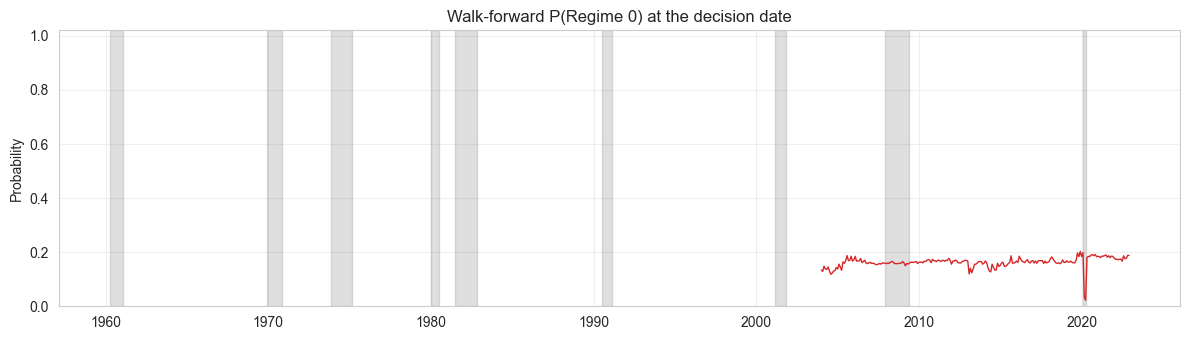

In [384]:
def fit_regime_window(X_window, n_typical=5, var_threshold=0.95, seed=42):
    '''
    Modified k-means on one 48-month window.

    Literal paper version:
    1. PCA to 95% variance.
    2. L2 k-means with k=2.
    3. Smaller cluster = Regime 0.
    4. Cosine k-means with r=5 on typical months.
    5. Soft probabilities via Equations (1)-(4).
    '''
    n_total = n_typical + 1

    # PCA.
    pca_full = PCA(random_state=seed).fit(X_window)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)
    n_pc = max(2, int(np.searchsorted(cum_var, var_threshold) + 1))

    pca = PCA(n_components=n_pc, random_state=seed).fit(X_window)
    X_pca_w = pca.transform(X_window)

    # L2 stage: literal smaller-cluster-as-outlier rule.
    km_l2 = KMeans(n_clusters=2, n_init=10, random_state=seed).fit(X_pca_w)
    sizes = np.bincount(km_l2.labels_)
    out_id = int(np.argmin(sizes))
    is_out = (km_l2.labels_ == out_id)

    l2_dists = km_l2.transform(X_pca_w)
    P_l2_w = distances_to_probs_eq1(l2_dists)
    P_outlier_w = P_l2_w[:, out_id]

    # Cosine stage on typical months.
    X_typical_w = X_pca_w[~is_out]
    X_typical_unit_w = l2_normalize_rows(X_typical_w)

    km_cos = KMeans(n_clusters=n_typical, n_init=10, random_state=seed).fit(X_typical_unit_w)

    # Discrete labels.
    labels = np.zeros(len(X_pca_w), dtype=int)
    labels[is_out] = 0
    labels[~is_out] = km_cos.labels_ + 1

    # Soft probabilities for all months.
    X_all_unit_w = l2_normalize_rows(X_pca_w)
    cos_dists_all_w = km_cos.transform(X_all_unit_w)
    P_cos_all_w = distances_to_probs_eq1(cos_dists_all_w)
    probs = combine_stages(P_outlier_w, P_cos_all_w)

    return {
        'labels': labels,
        'probs': probs,
        'transition': transition_matrix(labels, n_total),
        'n_pc': n_pc,
        'l2_sizes': sizes,
    }


def align_current_window_to_previous(prev_dates, prev_labels, curr_dates, curr_labels, curr_probs, n_regimes):
    '''
    Align current-window labels to previous-window labels using their overlapping months.
    This handles k-means label switching across rolling windows.
    '''
    prev_s = pd.Series(prev_labels, index=prev_dates)
    curr_s = pd.Series(curr_labels, index=curr_dates)

    shared = prev_s.index.intersection(curr_s.index)

    if len(shared) == 0:
        return curr_labels, curr_probs

    overlap = np.zeros((n_regimes, n_regimes))
    for curr_label in range(n_regimes):
        for prev_label in range(n_regimes):
            overlap[curr_label, prev_label] = np.sum(
                (curr_s.loc[shared].values == curr_label) &
                (prev_s.loc[shared].values == prev_label)
            )

    row_ind, col_ind = linear_sum_assignment(-overlap)

    perm = np.arange(n_regimes)
    perm[row_ind] = col_ind

    aligned_labels = perm[curr_labels]

    aligned_probs = np.zeros_like(curr_probs)
    for curr_label, prev_label in enumerate(perm):
        aligned_probs[:, prev_label] = curr_probs[:, curr_label]

    return aligned_labels, aligned_probs


def run_walk_forward_regimes(macro_panel, window=48, n_typical=5, seed=42, verbose_every=50):
    '''
    Run modified k-means at every month using only the past `window` months.
    Labels are matched across adjacent windows using the 47-month overlap.
    '''
    rolling = {}
    dates = macro_panel.index
    n_regimes = n_typical + 1

    prev_dates = None
    prev_labels = None

    for end_idx in range(window, len(dates) + 1):
        start_idx = end_idx - window
        window_dates = dates[start_idx:end_idx]
        decision_date = window_dates[-1]

        X_win = macro_panel.iloc[start_idx:end_idx].values
        X_std_w = StandardScaler().fit_transform(X_win)

        result = fit_regime_window(
            X_std_w,
            n_typical=n_typical,
            var_threshold=PCA_VAR_THRESHOLD,
            seed=seed,
        )

        if prev_dates is not None:
            aligned_labels, aligned_probs = align_current_window_to_previous(
                prev_dates=prev_dates,
                prev_labels=prev_labels,
                curr_dates=window_dates,
                curr_labels=result['labels'],
                curr_probs=result['probs'],
                n_regimes=n_regimes,
            )
            result['labels'] = aligned_labels
            result['probs'] = aligned_probs
            result['transition'] = transition_matrix(aligned_labels, n_regimes)

        result['window_dates'] = window_dates
        rolling[decision_date] = result

        prev_dates = window_dates
        prev_labels = result['labels']

        if verbose_every and (end_idx - window) % verbose_every == 0:
            n_outliers = int((result['labels'] == 0).sum())
            print(f"decision date {decision_date.date()}: outliers in window: {n_outliers}, n_pc={result['n_pc']}")

    return rolling


print(f"Running walk-forward regime detection over {len(data_macro_aligned)} months "
      f"with window {ESTIMATION_WINDOW}...")

rolling_regimes = run_walk_forward_regimes(
    data_macro_aligned,
    window=ESTIMATION_WINDOW,
    n_typical=N_TYPICAL_REGIMES,
    seed=RANDOM_SEED,
    verbose_every=50,
)

print(f"\nDone. {len(rolling_regimes)} decision dates.")

decision_dates = sorted(rolling_regimes.keys())
p0_current = pd.Series(
    [rolling_regimes[d]['probs'][-1, 0] for d in decision_dates],
    index=decision_dates,
)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(p0_current.index, p0_current.values, color='C3', linewidth=1.0)
shade_nber(ax)
ax.set_title('Walk-forward P(Regime 0) at the decision date')
ax.set_ylabel('Probability')
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 15. The Markov step (paper Equations 6, 7)

**Equation (6).** Renormalize the current regime distribution (in case of numerical drift):
$$
\tilde{\boldsymbol{p}}_t = \boldsymbol{p}_t / \|\boldsymbol{p}_t\|_1.
$$

**Equation (7).** Apply the transition matrix:
$$
\tilde{\boldsymbol{p}}_{t+1} = \tilde{\boldsymbol{p}}_t^\top E_t.
$$

Without the Markov step, you would predict the next month's regime as just being the current month's regime. The Markov step lets you weight in off-diagonal transition probabilities - useful especially near regime boundaries.

**Convention note.** Paper writes $\tilde{p}^\top E$ assuming $E$ is (FROM, TO). Our `transition_matrix` returns (TO, FROM) shaped $E$ to match the paper's plotting convention, so the equivalent code is $E \cdot \tilde p$. Mathematically identical.

In [385]:
def markov_step(p_current, E):
    '''
    Apply Eq (6) renormalization then Eq (7) one-step Markov transition.

    E is (TO, FROM): E[i, j] = P(regime t+1 = i | regime t = j).
    Paper's E is (FROM, TO), so paper's p_t^T E equals our E @ p_t.
    '''
    p_current = np.asarray(p_current, dtype=float)
    p_current = p_current / max(p_current.sum(), 1e-12)
    p_next = E @ p_current
    return p_next / max(p_next.sum(), 1e-12)


# Quick check.
test_dec = decision_dates[100]
test_pkg = rolling_regimes[test_dec]
p_t = test_pkg['probs'][-1]
p_t_next = markov_step(p_t, test_pkg['transition'])
print(f"Sample at {test_dec.date()}:")
print(f"  p_t:      {p_t.round(3)}")
print(f"  p_t_next: {p_t_next.round(3)}")


Sample at 2012-05-01:
  p_t:      [0.168 0.178 0.113 0.175 0.176 0.191]
  p_t_next: [0.085 0.118 0.161 0.209 0.275 0.152]


## 16. Forecasting models (paper Section 5.2)

### 16.1 Naive forecast (Eqs 8-10)

Most likely next regime $i^* = \arg\max_i \tilde p_{i, t+1}$. Forecast = regime-conditional sample Sharpe ratio:
$$
\hat y^{j, \text{naive}}_{t+1} = \hat\mu^{*}_{j, 1:t} / \hat\sigma^{*}_{j, 1:t}.
$$

### 16.2 Black-Litterman views (Eq 11)

$$
q^{*}_{j, t+1} = \mathbb{E}[r^{j}_{t+1} \mid \text{Regime} = i^*_{t+1}] = \hat\mu^{*}_{j, 1:t}.
$$

### 16.3 Ridge forecast (Eqs 12-14)

For each typical regime $i$, fit ridge of returns on macro PCA features using only window months in that regime. Aggregate over regimes weighted by the predicted regime distribution:
$$
\hat y^{j, \text{ridge}}_{t+1} = \sum_{i=1}^{r} \tilde p_{i, t+1} \cdot \hat{\boldsymbol\beta}^{i,j}_{\text{ridge}} \boldsymbol{x}^{i}_{t}.
$$

In [386]:
def regime_conditional_stats(window_returns, window_labels, n_regimes, ddof=1):
    '''Sample mean and std of returns within each regime in the window.'''
    n_assets = window_returns.shape[1]
    mu = np.full((n_regimes, n_assets), np.nan)
    sigma = np.full((n_regimes, n_assets), np.nan)
    for i in range(n_regimes):
        mask = (window_labels == i)
        if mask.sum() >= 2:
            sub = window_returns[mask]
            mu[i] = sub.mean(axis=0)
            sigma[i] = sub.std(axis=0, ddof=ddof)
    return mu, sigma


def naive_forecast(p_t_next, mu_regime, sigma_regime, mu_overall, sigma_overall):
    '''Eq (9): Sharpe under most-likely next regime, with overall fallback.'''
    i_star = int(np.argmax(p_t_next))
    mu_i = mu_regime[i_star]
    sigma_i = sigma_regime[i_star]
    if np.any(np.isnan(mu_i)) or np.any(np.isnan(sigma_i)):
        mu_i = mu_overall
        sigma_i = sigma_overall
    sigma_i = np.where(sigma_i == 0, 1e-12, sigma_i)
    return mu_i / sigma_i


def bl_views(p_t_next, mu_regime, mu_overall):
    '''Eq (11): regime-conditional expected return as the BL view.'''
    i_star = int(np.argmax(p_t_next))
    mu_i = mu_regime[i_star]
    if np.any(np.isnan(mu_i)):
        mu_i = mu_overall
    return mu_i


def ridge_forecast(
    p_t_next, window_macro_pca, window_returns, window_labels,
    macro_pca_t, n_typical_regimes, ridge_alpha=2.0,
):
    '''
    Regime-conditional ridge forecast.

    Training alignment:
        macro features at s  ->  ETF return at s+1

    This avoids training a contemporaneous macro-return relation and then using it
    as if it were a one-month-ahead model.
    '''
    n_assets = window_returns.shape[1]

    # Need at least one forward step.
    if len(window_returns) < 2:
        return window_returns.mean(axis=0)

    X_train_all = window_macro_pca[:-1]
    Y_next_all = window_returns[1:]
    labels_for_X = window_labels[:-1]

    pred = np.zeros(n_assets)
    weight_sum = 0.0

    for i in range(1, n_typical_regimes + 1):
        mask = (labels_for_X == i)

        if mask.sum() < 3:
            continue

        X_i = X_train_all[mask]
        y_i = Y_next_all[mask]

        try:
            ridge = Ridge(alpha=ridge_alpha, fit_intercept=True).fit(X_i, y_i)
            pred_i = ridge.predict(macro_pca_t.reshape(1, -1)).ravel()
        except Exception:
            continue

        w_i = p_t_next[i]
        pred += w_i * pred_i
        weight_sum += w_i

    if weight_sum > 0:
        pred /= weight_sum
    else:
        pred = window_returns.mean(axis=0)

    return pred


## 17. Position sizing schemes (paper Eqs 15-18)

Given a vector of forecasts $\hat{\boldsymbol{y}}_{t+1} \in \mathbb{R}^d$ across $d$ ETFs:

- **Long-and-short (lns)**: top $\mathcal{l}$ longs and bottom-$\ell$ shorts, weighted by forecasts.
- **Long-or-short (los)**: top $\mathcal{l}$ by **magnitude**, sign preserved.
- **Long-only (lo)**: top $\mathcal{l}$ longs only.
- **Mixed (mx)**: los if next regime is most likely Regime 0 (crisis), else lo.

All weights are normalized so $\sum |w_j| = 1$.

In [387]:
def size_positions(forecasts, scheme='lo', l=3, next_regime_is_crisis=False):
    '''Convert forecasts to weights under one of the four sizing schemes.'''
    y = np.asarray(forecasts, dtype=float)
    d = len(y)

    if scheme == 'mx':
        scheme = 'los' if next_regime_is_crisis else 'lo'

    sort_desc = np.argsort(-y)
    H = sort_desc[:l]
    L = sort_desc[-l:]
    weights = np.zeros(d)

    if scheme == 'lns':
        H_pos = [j for j in H if y[j] > 0]
        L_neg = [j for j in L if y[j] < 0]
        idx = list(H_pos) + list(L_neg)
        if not idx:
            return weights
        S = sum(abs(y[j]) for j in idx)
        if S == 0:
            return weights
        for j in idx:
            weights[j] = y[j] / S
    elif scheme == 'lo':
        H_pos = [j for j in H if y[j] > 0]
        if not H_pos:
            return weights
        S = sum(abs(y[j]) for j in H_pos)
        if S == 0:
            return weights
        for j in H_pos:
            weights[j] = y[j] / S
    elif scheme == 'los':
        mag_order = np.argsort(-np.abs(y))[:l]
        S = sum(abs(y[j]) for j in mag_order)
        if S == 0:
            return weights
        for j in mag_order:
            weights[j] = y[j] / S
    else:
        raise ValueError(f"Unknown sizing scheme: {scheme}")

    return weights


## 18. Black-Litterman portfolio (paper Eq 19) and MVO baseline

Black-Litterman posterior mean (paper Eq 19):
$$
\boldsymbol{\mu}_{\text{BL}} = \left[(\tau \boldsymbol{\Sigma})^{-1} + P^\top \Omega^{-1} P\right]^{-1} \left[(\tau \boldsymbol{\Sigma})^{-1} \hat{\boldsymbol{\mu}} + P^\top \Omega^{-1} \boldsymbol{q}\right]
$$

We use absolute views on each ETF, so $P = I$. We set $\Omega = \mathrm{diag}(\tau \boldsymbol{\Sigma})$ (He-Litterman convention).

Final weights via tangency: $\boldsymbol{w} = \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_{\text{BL}}$, normalized to $\sum |w_j| = 1$.

In [388]:
# Note: the paper does not fully specify P, Omega, or the final optimizer details.
# This is a transparent Black-Litterman implementation using P=I and Omega=diag(tau*Sigma)

def black_litterman_weights(mu_sample, Sigma_sample, q_views, tau=0.05, ridge=1e-6):
    '''BL posterior mean and tangency weights with absolute views (P = I).'''
    d = len(mu_sample)
    I = np.eye(d)
    Omega = np.diag(np.diag(tau * Sigma_sample))
    Omega_inv = np.linalg.inv(Omega + ridge * I)
    tau_Sigma = tau * Sigma_sample
    tau_Sigma_inv = np.linalg.inv(tau_Sigma + ridge * I)
    posterior_prec = tau_Sigma_inv + Omega_inv
    posterior_mean = np.linalg.solve(
        posterior_prec, tau_Sigma_inv @ mu_sample + Omega_inv @ q_views,
    )
    raw_w = np.linalg.solve(Sigma_sample + ridge * I, posterior_mean)
    abs_sum = np.sum(np.abs(raw_w))
    weights = np.zeros(d) if abs_sum < 1e-12 else raw_w / abs_sum
    return weights, posterior_mean


def mvo_weights(mu_sample, Sigma_sample, ridge=1e-6, long_only=False):
    '''Standard MVO tangency weights (the paper's MVO baseline).'''
    d = len(mu_sample)
    I = np.eye(d)
    raw_w = np.linalg.solve(Sigma_sample + ridge * I, mu_sample)
    if long_only:
        raw_w = np.clip(raw_w, 0, None)
    abs_sum = np.sum(np.abs(raw_w))
    if abs_sum < 1e-12:
        return np.zeros(d)
    return raw_w / abs_sum


## 19. Walk-forward backtest

Glue everything together. At each decision date $t$:

1. Get the rolling regime fit: window labels, soft probabilities, transition matrix.
2. Apply the Markov step: $\tilde{\boldsymbol{p}}_{t+1} = E \tilde{\boldsymbol{p}}_t$.
3. Compute regime-conditional asset stats from window returns and labels.
4. Build forecast under each model (Naive / BL / Ridge / MVO).
5. Convert forecast to weights under each sizing scheme.
6. Realize next-month return = $\boldsymbol{w}_{t+1}^\top \boldsymbol{r}_{t+1}$.

In [389]:
def walk_forward_backtest(
    etf_returns, macro_panel, rolling_regimes,
    n_typical_regimes=5, l_grid=(2, 3, 4),
    ridge_alpha=1.0, bl_tau=0.05,
):
    '''
    Run all backtests in one pass. Returns a DataFrame indexed by date,
    one column per strategy.
    '''
    n_total_regimes = n_typical_regimes + 1
    decision_dates = sorted(rolling_regimes.keys())
    asset_names = list(etf_returns.columns)
    n_assets = len(asset_names)

    out_returns = {}

    for t_idx, t in enumerate(decision_dates):
        if t_idx >= len(decision_dates) - 1:
            break
        t_next = decision_dates[t_idx + 1]
        r_next = etf_returns.loc[t_next].values
        if np.any(np.isnan(r_next)):
            continue

        pkg = rolling_regimes[t]
        labels = pkg['labels']
        probs = pkg['probs']
        E = pkg['transition']
        win_dates = pkg['window_dates']
        win_ret = etf_returns.loc[win_dates].values
        win_macro = macro_panel.loc[win_dates].values

        p_t = probs[-1]
        p_next = markov_step(p_t, E)

        mu_reg, sigma_reg = regime_conditional_stats(win_ret, labels, n_total_regimes)
        mu_all = win_ret.mean(axis=0)
        sigma_all = win_ret.std(axis=0, ddof=1)
        Sigma_all = np.cov(win_ret, rowvar=False, ddof=1)

        # Macro PCA features for ridge.
        scaler_w = StandardScaler().fit(win_macro)
        win_macro_std = scaler_w.transform(win_macro)
        n_pc = min(10, win_macro_std.shape[1])
        pca_w = PCA(n_components=n_pc, random_state=RANDOM_SEED).fit(win_macro_std)
        win_macro_pca = pca_w.transform(win_macro_std)
        macro_at_t = win_macro_pca[-1]

        # Forecasts.
        y_naive = naive_forecast(p_next, mu_reg, sigma_reg, mu_all, sigma_all)
        y_ridge = ridge_forecast(
            p_next, win_macro_pca, win_ret, labels, macro_at_t,
            n_typical_regimes, ridge_alpha=ridge_alpha,
        )
        q_bl = bl_views(p_next, mu_reg, mu_all)

        i_star = int(np.argmax(p_next))
        crisis_next = (i_star == 0)

        ret_dict = {}

        # Naive + each sizing + each l.
        for l in l_grid:
            for sch in ('lo', 'lns', 'los', 'mx'):
                w = size_positions(y_naive, scheme=sch, l=l, next_regime_is_crisis=crisis_next)
                ret_dict[f'naive_{sch}_{l}'] = w @ r_next

        # Ridge + each sizing + each l.
        for l in l_grid:
            for sch in ('lo', 'lns', 'los', 'mx'):
                w = size_positions(y_ridge, scheme=sch, l=l, next_regime_is_crisis=crisis_next)
                ret_dict[f'ridge_{sch}_{l}'] = w @ r_next

        # MVO baseline.
        mvo_full_lo = mvo_weights(mu_all, Sigma_all, long_only=True)
        mvo_full_lns = mvo_weights(mu_all, Sigma_all, long_only=False)
        for l in l_grid:
            for w_full, sch in ((mvo_full_lo, 'lo'), (mvo_full_lns, 'lns')):
                if np.sum(np.abs(w_full)) > 0:
                    keep = np.argsort(-np.abs(w_full))[:l]
                    w = np.zeros(n_assets)
                    w[keep] = w_full[keep]
                    s = np.sum(np.abs(w))
                    if s > 0:
                        w = w / s
                    ret_dict[f'mvo_{sch}_{l}'] = w @ r_next
                else:
                    ret_dict[f'mvo_{sch}_{l}'] = 0.0

        # Black-Litterman + each l.
        for l in l_grid:
            w_bl_full, _ = black_litterman_weights(mu_all, Sigma_all, q_bl, tau=bl_tau)
            for sch in ('lo', 'lns'):
                w_bl = np.clip(w_bl_full, 0, None) if sch == 'lo' else w_bl_full.copy()
                if np.sum(np.abs(w_bl)) > 0:
                    keep = np.argsort(-np.abs(w_bl))[:l]
                    w = np.zeros(n_assets)
                    w[keep] = w_bl[keep]
                    s = np.sum(np.abs(w))
                    if s > 0:
                        w = w / s
                    ret_dict[f'bl_{sch}_{l}'] = w @ r_next
                else:
                    ret_dict[f'bl_{sch}_{l}'] = 0.0

        # Benchmarks.
        ew = np.ones(n_assets) / n_assets
        ret_dict['ew'] = ew @ r_next
        if 'SPY' in asset_names:
            ret_dict['spy'] = r_next[asset_names.index('SPY')]

        out_returns[t_next] = ret_dict

    return pd.DataFrame.from_dict(out_returns, orient='index').sort_index()


print("Running walk-forward backtest...")
bt_returns = walk_forward_backtest(
    etf_returns_aligned, data_macro_aligned, rolling_regimes,
    n_typical_regimes=N_TYPICAL_REGIMES, l_grid=(2, 3, 4),
)
print(f"Backtest output shape: {bt_returns.shape}")
print(f"Date range: {bt_returns.index.min().date()} to {bt_returns.index.max().date()}")
print(f"Total strategies: {len(bt_returns.columns)}")


Running walk-forward backtest...
Backtest output shape: (227, 38)
Date range: 2004-02-01 to 2022-12-01
Total strategies: 38


## 20. Volatility scaling (paper Section 6, Figure 10)

The paper reports cumulative log returns "with 10% volatility scaling": every strategy is rescaled to have a target annualized volatility of 10% based on a trailing volatility estimate. This makes strategies comparable on a risk-adjusted basis.

At each month $t$, scale the strategy's return by $\sigma_{\text{target}} / \hat\sigma^{\text{trailing}}_t$ where the trailing vol is shifted by 1 to avoid contemporaneous information.

In [390]:
def vol_scale(returns_df, target_annual_vol=0.10, lookback=12):
    '''Rescale each return series to a target annualized volatility.'''
    monthly_target = target_annual_vol / np.sqrt(12)
    out = returns_df.copy() * np.nan
    for col in returns_df.columns:
        s = returns_df[col]
        roll_vol = s.rolling(lookback, min_periods=lookback).std().shift(1)
        scale = monthly_target / roll_vol.replace(0, np.nan)
        out[col] = s * scale
    return out


bt_returns_scaled = vol_scale(bt_returns, target_annual_vol=0.10, lookback=12).dropna(how='all')
print(f"After vol scaling: {bt_returns_scaled.shape}")
print(f"Date range:        {bt_returns_scaled.index.min().date()} to {bt_returns_scaled.index.max().date()}")


After vol scaling: (215, 38)
Date range:        2005-02-01 to 2022-12-01


## 21. Performance metrics (paper Section 5.4) and Tables 4-6

In [391]:
def compute_metrics(returns_df):
    '''Sharpe, Sortino, AvgDD (%), MaxDD (%), % positive returns.'''
    rows = []

    for col in returns_df.columns:
        s = returns_df[col].dropna()

        if len(s) < 12:
            continue

        mu = s.mean()
        sd = s.std(ddof=1)
        sharpe = np.sqrt(12) * mu / sd if sd > 0 else np.nan

        downside = s[s < 0]
        sd_down = downside.std(ddof=1) if len(downside) > 1 else np.nan
        sortino = np.sqrt(12) * mu / sd_down if pd.notna(sd_down) and sd_down > 0 else np.nan

        cum = np.log1p(s).cumsum()
        running_max = cum.cummax()
        dd = cum - running_max

        avg_dd_pct = 100 * (np.exp(dd[dd < 0].mean()) - 1) if (dd < 0).any() else 0.0
        max_dd_pct = 100 * (np.exp(dd.min()) - 1)

        pct_pos = (s > 0).mean()

        rows.append({
            'strategy': col,
            'Sharpe': sharpe,
            'Sortino': sortino,
            'AvgDD': avg_dd_pct,
            'MaxDD': max_dd_pct,
            'PctPositive': pct_pos,
        })

    return pd.DataFrame(rows).set_index('strategy')


metrics = compute_metrics(bt_returns_scaled)
print("Top 15 strategies by Sharpe ratio:")
print(metrics.sort_values('Sharpe', ascending=False).head(15).round(3))

Top 15 strategies by Sharpe ratio:
            Sharpe  Sortino   AvgDD   MaxDD  PctPositive
strategy                                                
ridge_lo_2   0.907    1.121  -5.174 -21.557        0.619
ridge_mx_2   0.879    1.117  -5.197 -21.557        0.614
naive_lo_4   0.848    1.198  -7.058 -25.840        0.647
bl_lo_2      0.845    1.229  -9.378 -32.710        0.642
naive_lo_3   0.843    1.192  -7.417 -25.797        0.637
ridge_lo_4   0.815    1.015  -6.455 -25.693        0.609
ridge_mx_4   0.811    1.034  -6.466 -25.693        0.605
naive_lo_2   0.804    1.230  -7.215 -24.527        0.628
mvo_lo_2     0.799    1.210  -9.864 -33.845        0.637
ridge_lo_3   0.782    0.958  -6.033 -24.273        0.600
ridge_mx_3   0.778    0.975  -6.046 -24.273        0.595
naive_mx_4   0.770    1.096  -6.676 -25.618        0.628
bl_lo_3      0.762    1.095 -11.098 -35.896        0.642
naive_mx_3   0.761    1.093  -7.069 -25.587        0.614
bl_lo_4      0.760    1.088 -11.156 -36.870        0.

In [392]:
def make_paper_table(metrics_df, prefix, mvo=True, benchmarks=True):
    '''Pull rows for one model family + benchmarks into a clean table.'''
    rows = [r for r in metrics_df.index if r.startswith(prefix + '_')]
    if mvo:
        rows += sorted(r for r in metrics_df.index if r.startswith('mvo_'))
    if benchmarks:
        rows += [r for r in ('spy', 'ew') if r in metrics_df.index]
    return metrics_df.loc[[r for r in rows if r in metrics_df.index]].round(3)


print("=== Table 4 analogue: Naive vs MVO and benchmarks ===")
print(make_paper_table(metrics, 'naive'))

print("\n=== Table 5 analogue: BL vs MVO and benchmarks ===")
print(make_paper_table(metrics, 'bl'))

print("\n=== Table 6 analogue: Ridge vs MVO and benchmarks ===")
print(make_paper_table(metrics, 'ridge'))


=== Table 4 analogue: Naive vs MVO and benchmarks ===
             Sharpe  Sortino   AvgDD   MaxDD  PctPositive
strategy                                                 
naive_lo_2    0.804    1.230  -7.215 -24.527        0.628
naive_lns_2   0.668    1.019  -6.781 -21.285        0.591
naive_los_2   0.620    0.993  -6.658 -21.748        0.591
naive_mx_2    0.734    1.131  -6.994 -24.527        0.609
naive_lo_3    0.843    1.192  -7.417 -25.797        0.637
naive_lns_3   0.700    1.002  -6.858 -21.966        0.605
naive_los_3   0.699    1.039  -6.526 -22.728        0.595
naive_mx_3    0.761    1.093  -7.069 -25.587        0.614
naive_lo_4    0.848    1.198  -7.058 -25.840        0.647
naive_lns_4   0.688    0.977  -6.810 -22.202        0.614
naive_los_4   0.685    1.017  -6.326 -24.532        0.614
naive_mx_4    0.770    1.096  -6.676 -25.618        0.628
mvo_lns_2    -0.432   -0.766 -47.647 -72.476        0.391
mvo_lns_3    -0.296   -0.504 -41.165 -66.684        0.409
mvo_lns_4    -0.24

In [393]:
def make_random_rolling_regimes(rolling_regimes, n_regimes, seed=0):
    '''
    Random-regime control.

    For each rolling window, randomly permute the labels within that window.
    This preserves the marginal regime counts in each window but destroys the
    time-regime structure.
    '''
    rng = np.random.default_rng(seed)
    randomized = {}

    for d, pkg in rolling_regimes.items():
        labels = np.asarray(pkg['labels']).copy()
        rand_labels = rng.permutation(labels)

        probs = np.zeros_like(pkg['probs'])
        probs[np.arange(len(rand_labels)), rand_labels] = 1.0

        randomized[d] = {
            **pkg,
            'labels': rand_labels,
            'probs': probs,
            'transition': transition_matrix(rand_labels, n_regimes),
        }

    return randomized


N_RANDOM_CONTROLS = 30
random_control_metrics = []

for seed in range(N_RANDOM_CONTROLS):
    rand_rolling = make_random_rolling_regimes(
        rolling_regimes,
        n_regimes=N_TYPICAL_REGIMES + 1,
        seed=1000 + seed,
    )

    rand_returns = walk_forward_backtest(
        etf_returns_aligned,
        data_macro_aligned,
        rand_rolling,
        n_typical_regimes=N_TYPICAL_REGIMES,
        l_grid=(2, 3, 4),
    )

    rand_scaled = vol_scale(rand_returns, target_annual_vol=0.10, lookback=12).dropna(how='all')
    rand_metrics = compute_metrics(rand_scaled)
    rand_metrics['random_seed'] = seed
    random_control_metrics.append(rand_metrics.reset_index())

random_control_metrics = pd.concat(random_control_metrics, ignore_index=True)

print("Random-regime controls complete.")
print(random_control_metrics.head())

Random-regime controls complete.
      strategy    Sharpe   Sortino      AvgDD      MaxDD  PctPositive  \
0   naive_lo_2  0.583253  0.797854  -9.242232 -27.277536     0.618605   
1  naive_lns_2  0.230363  0.274567 -13.486323 -30.819967     0.558140   
2  naive_los_2  0.303651  0.394529 -10.015382 -21.805449     0.600000   
3   naive_mx_2  0.538050  0.711802  -9.430154 -26.197436     0.618605   
4   naive_lo_3  0.619307  0.829509  -8.408985 -24.560048     0.623256   

   random_seed  
0            0  
1            0  
2            0  
3            0  
4            0  


In [394]:
# Compare real-regime strategies to random-regime controls.
real_metrics_long = metrics.reset_index().rename(columns={'index': 'strategy'})
real_metrics_long['random_seed'] = 'real'

summary_random = (
    random_control_metrics
    .groupby('strategy')[['Sharpe', 'Sortino', 'AvgDD', 'MaxDD', 'PctPositive']]
    .agg(['mean', 'std'])
)

print("Random-regime metric summary:")
print(summary_random.round(3).head(20))


def paired_real_vs_random_test(strategy, metric):
    real_value = metrics.loc[strategy, metric]
    rand_values = random_control_metrics.loc[
        random_control_metrics['strategy'] == strategy, metric
    ].dropna()

    if len(rand_values) < 2:
        return np.nan

    # One-sample version against the real value.
    # H0 roughly: random metric >= real metric.
    # This is not exactly the paper's Nemenyi test, but is a transparent diagnostic.
    diffs = real_value - rand_values.values
    tstat, p_two_sided = ttest_rel(
        np.full_like(diffs, real_value, dtype=float),
        rand_values.values,
    )
    return p_two_sided / 2 if np.nanmean(diffs) > 0 else 1.0


test_rows = []
for strategy in metrics.index:
    if strategy.startswith(('naive_', 'ridge_', 'bl_')):
        row = {'strategy': strategy}
        for metric in ['Sharpe', 'Sortino', 'MaxDD', 'PctPositive']:
            row[f'p_real_better_{metric}'] = paired_real_vs_random_test(strategy, metric)
        test_rows.append(row)

random_tests = pd.DataFrame(test_rows).set_index('strategy')
print("Real-vs-random p-value diagnostics:")
print(random_tests.round(4).head(20))

Random-regime metric summary:
            Sharpe        Sortino          AvgDD          MaxDD          \
              mean    std    mean    std    mean    std    mean     std   
strategy                                                                  
bl_lns_2    -0.467  0.061  -0.767  0.075 -48.391  1.780 -74.729   2.610   
bl_lns_3    -0.303  0.076  -0.455  0.092 -42.286  2.868 -69.487   4.312   
bl_lns_4    -0.189  0.120  -0.259  0.152 -35.845  4.889 -63.171   7.002   
bl_lo_2      0.789  0.038   1.158  0.063 -10.466  1.000 -34.524   2.015   
bl_lo_3      0.741  0.032   1.067  0.053 -10.934  1.102 -35.338   2.091   
bl_lo_4      0.733  0.029   1.047  0.053 -11.340  0.876 -36.899   1.937   
ew           0.703  0.000   0.954  0.000 -11.587  0.000 -37.309   0.000   
mvo_lns_2   -0.432  0.000  -0.766  0.000 -47.647  0.000 -72.476   0.000   
mvo_lns_3   -0.296  0.000  -0.504  0.000 -41.165  0.000 -66.684   0.000   
mvo_lns_4   -0.247  0.000  -0.365  0.000 -35.301  0.000 -63.221   0.00

In [395]:
def collect_real_and_random(family_prefix, metric):
    '''
    For one model family (e.g. 'naive') and one metric (e.g. 'Sharpe'),
    pull the real-regime metric values and the random-regime metric values.

    Returns
    -------
    real_arr  : ndarray, one value per strategy in the family (length 12 for
                naive/ridge with 4 sizing schemes x 3 ell values, 6 for BL with
                2 schemes x 3 ell values).
    rand_arr  : ndarray of shape (n_random_seeds, n_strategies). Random metric
                value for each seed, each strategy.
    strategies: list of strategy names corresponding to the column order.
    '''
    family_strats = sorted([s for s in metrics.index if s.startswith(family_prefix + '_')])

    # Real-regime metric values (one per strategy).
    real_arr = metrics.loc[family_strats, metric].values

    # Random-regime metric values (one per seed per strategy).
    rand_pivot = (
        random_control_metrics[random_control_metrics['strategy'].isin(family_strats)]
        .pivot_table(index='random_seed', columns='strategy', values=metric)
        .reindex(columns=family_strats)
    )
    rand_arr = rand_pivot.values

    return real_arr, rand_arr, family_strats


def paired_t_pvalue_one_sided(real_arr, rand_arr):
    '''
    Paired t-test, H0: control mean >= treatment mean (paper's H0).

    For each strategy in the family, compute (real - mean(random_for_that_strategy)).
    Then test whether the mean of those differences is > 0.

    Returns
    -------
    p_one_sided : float
    '''
    # Per strategy, take the mean random metric across seeds.
    rand_means_per_strategy = np.nanmean(rand_arr, axis=0)
    diffs = real_arr - rand_means_per_strategy
    if len(diffs) < 2:
        return np.nan
    tstat, p_two_sided = ttest_rel(real_arr, rand_means_per_strategy)
    # One-sided: alternative is treatment > control.
    return p_two_sided / 2 if tstat > 0 else 1.0 - p_two_sided / 2


def plot_random_vs_real_boxplots(family_prefix, family_label):
    '''Reproduce paper Figures 7/8/9: 2x2 grid of metric boxplots, control vs treatment.'''
    metrics_to_plot = ['Sharpe', 'Sortino', 'MaxDD', 'PctPositive']
    metric_pretty = {'Sharpe': 'Sharpe', 'Sortino': 'Sortino',
                     'MaxDD': 'MaxDD', 'PctPositive': '% Positive Ret.'}

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    axes = axes.flatten()

    for ax, metric in zip(axes, metrics_to_plot):
        real_arr, rand_arr, _ = collect_real_and_random(family_prefix, metric)

        # Control: pool all (strategy, seed) pairs into one box.
        rand_flat = rand_arr.flatten()
        rand_flat = rand_flat[~np.isnan(rand_flat)]

        # Treatment: one value per strategy.
        real_flat = real_arr[~np.isnan(real_arr)]

        bp = ax.boxplot(
            [rand_flat, real_flat],
            widths=0.5, patch_artist=True,
        )
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Control', 'Treatment'])
        for patch, color in zip(bp['boxes'], ['lightcoral', 'lightblue']):
            patch.set_facecolor(color)

        # Annotate one-sided paired t-test p-value.
        p_val = paired_t_pvalue_one_sided(real_arr, rand_arr)
        ax.text(0.05, 0.05,
                f'p-value: {p_val:.3f} ($H_0$: $\\mu_c \\geq \\mu_t$)',
                transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

        ax.set_ylabel(metric_pretty[metric])
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'{family_label} with Random Regime (control) vs not Random Regime (treatment)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

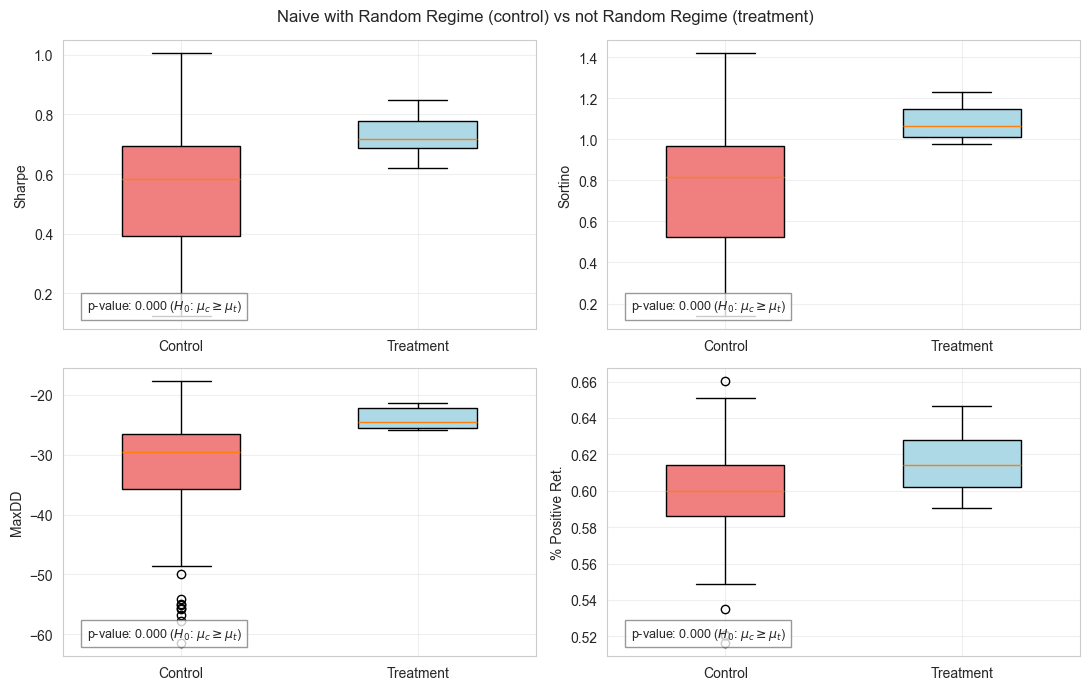

In [396]:
# Figure 7 analogue: Naive forecaster, real vs random regimes
plot_random_vs_real_boxplots('naive', 'Naive')

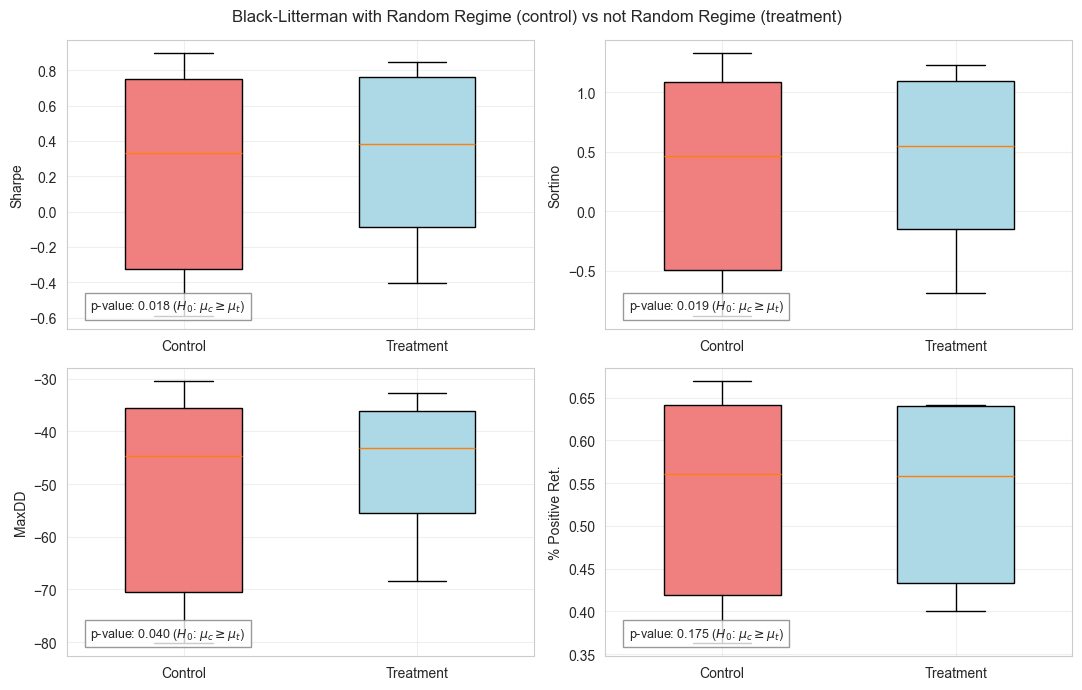

In [397]:
# Figure 8 analogue: Black-Litterman, real vs random regimes
plot_random_vs_real_boxplots('bl', 'Black-Litterman')

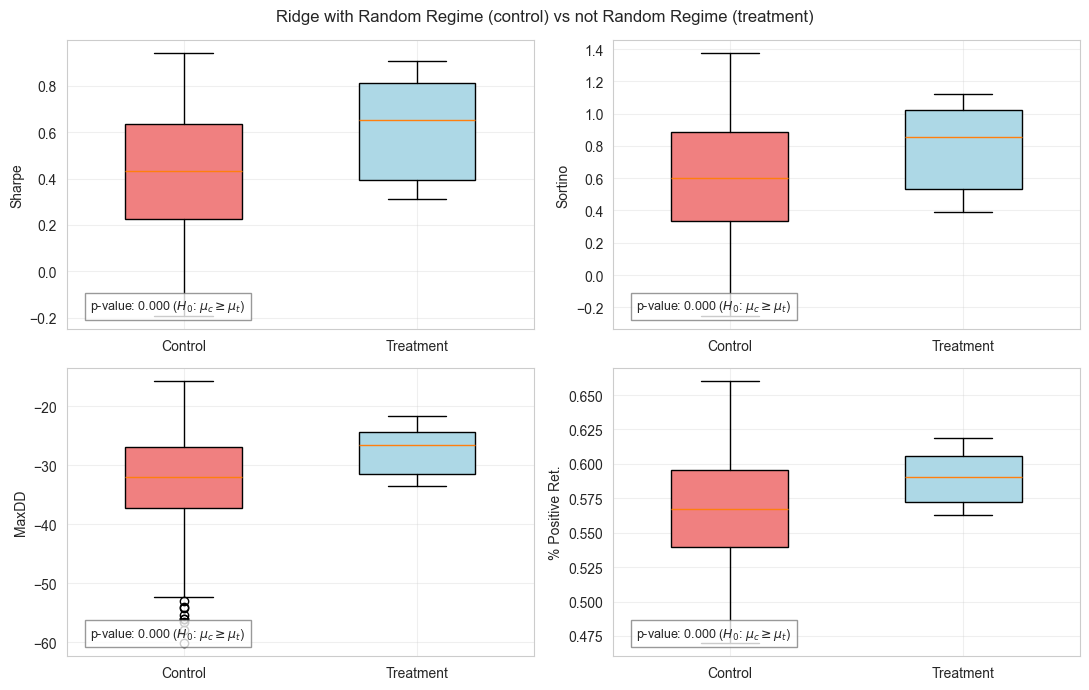

In [398]:
# Figure 9 analogue: Ridge, real vs random regimes
plot_random_vs_real_boxplots('ridge', 'Ridge')

## 22. Cumulative return plots (paper Figures 10, 13)

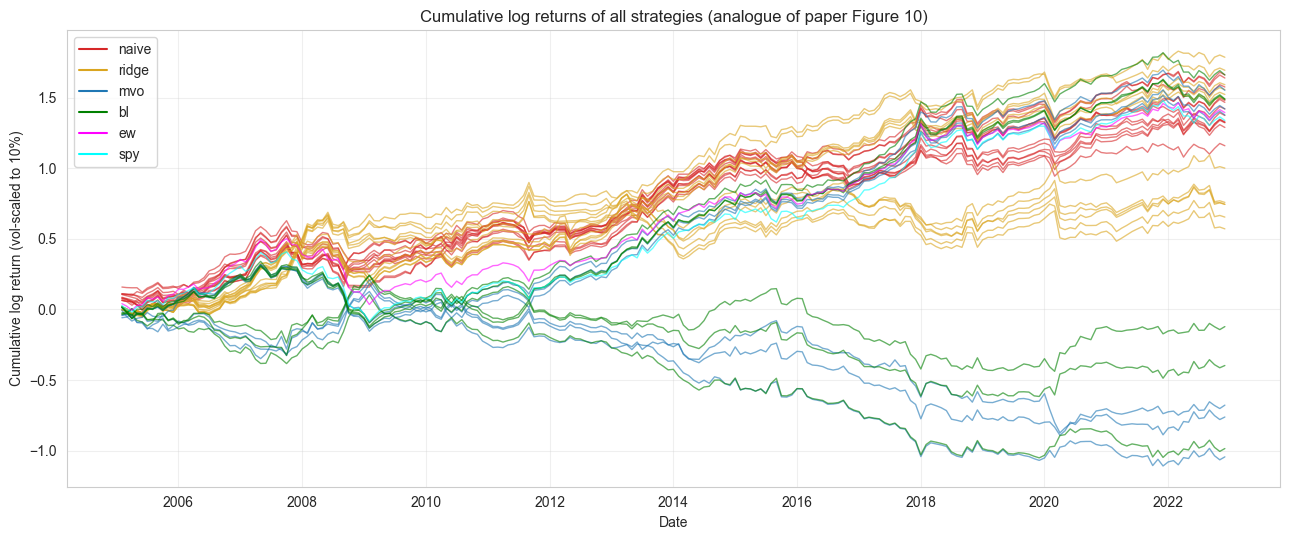

In [399]:
def plot_cum_returns_by_family(returns_df, title=''):
    '''Plot cumulative log returns, color-coded by model family.'''
    families = {}
    cmap = {'naive': 'C3', 'ridge': 'goldenrod', 'mvo': 'C0',
            'bl': 'green', 'spy': 'cyan', 'ew': 'magenta'}
    for col in returns_df.columns:
        for prefix, color in cmap.items():
            if col == prefix or col.startswith(prefix + '_'):
                families.setdefault(color, []).append(col)
                break

    fig, ax = plt.subplots(figsize=(13, 5.5))
    for color, cols in families.items():
        for col in cols:
            cum = np.log1p(returns_df[col]).cumsum()
            ax.plot(cum.index, cum.values, color=color, alpha=0.6, linewidth=1.0)
        if cols:
            ax.plot([], [], color=color, label=cols[0].split('_')[0])
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative log return (vol-scaled to 10%)')
    ax.set_title(title)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()


plot_cum_returns_by_family(
    bt_returns_scaled,
    title='Cumulative log returns of all strategies (analogue of paper Figure 10)',
)


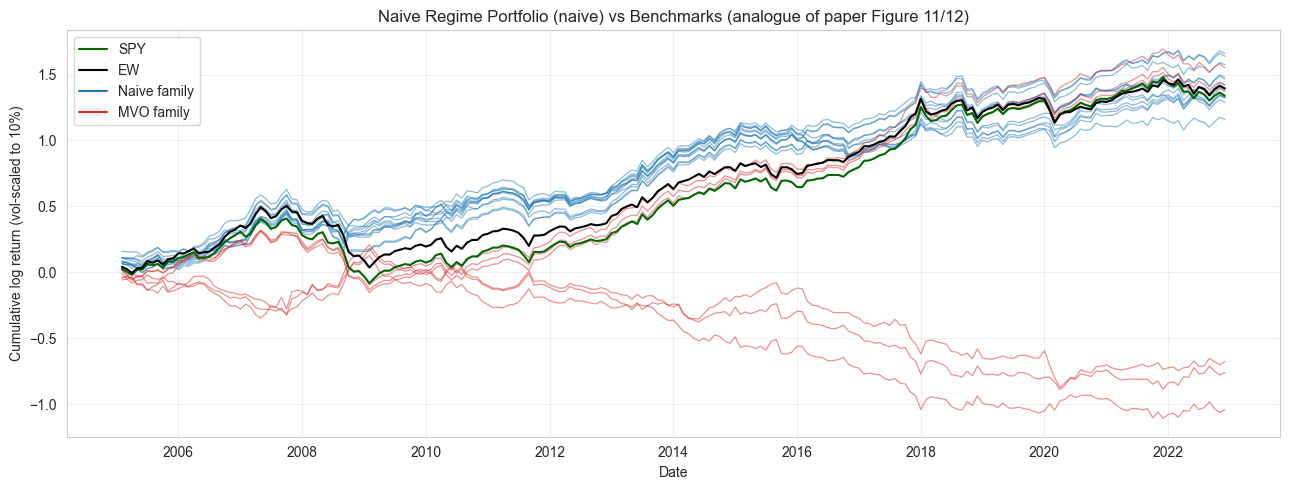

In [400]:
# Figure 11 analogue: Naive cumulative log returns vs MVO and benchmarks
def plot_family_vs_benchmarks(family_prefix, family_color, family_label):
    '''Cumulative log returns: family in one color, MVO in another, SPY/EW as solid lines.'''
    fig, ax = plt.subplots(figsize=(13, 5))

    # Family lines.
    for col in bt_returns_scaled.columns:
        if col.startswith(family_prefix + '_'):
            cum = np.log1p(bt_returns_scaled[col]).cumsum()
            ax.plot(cum.index, cum.values, color=family_color, alpha=0.5, linewidth=0.9)

    # MVO lines.
    for col in bt_returns_scaled.columns:
        if col.startswith('mvo_'):
            cum = np.log1p(bt_returns_scaled[col]).cumsum()
            ax.plot(cum.index, cum.values, color='C3', alpha=0.5, linewidth=0.9)

    # Benchmarks: thicker solid lines.
    for col, color, label in [('spy', 'darkgreen', 'SPY'), ('ew', 'k', 'EW')]:
        if col in bt_returns_scaled.columns:
            cum = np.log1p(bt_returns_scaled[col]).cumsum()
            ax.plot(cum.index, cum.values, color=color, linewidth=1.5, label=label)

    # Legend handles.
    ax.plot([], [], color=family_color, label=f'{family_label} family')
    ax.plot([], [], color='C3', label='MVO family')

    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative log return (vol-scaled to 10%)')
    ax.set_title(f'{family_label} Regime Portfolio ({family_prefix}) vs Benchmarks '
                 f'(analogue of paper Figure 11/12)')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()


plot_family_vs_benchmarks('naive', 'C0', 'Naive')

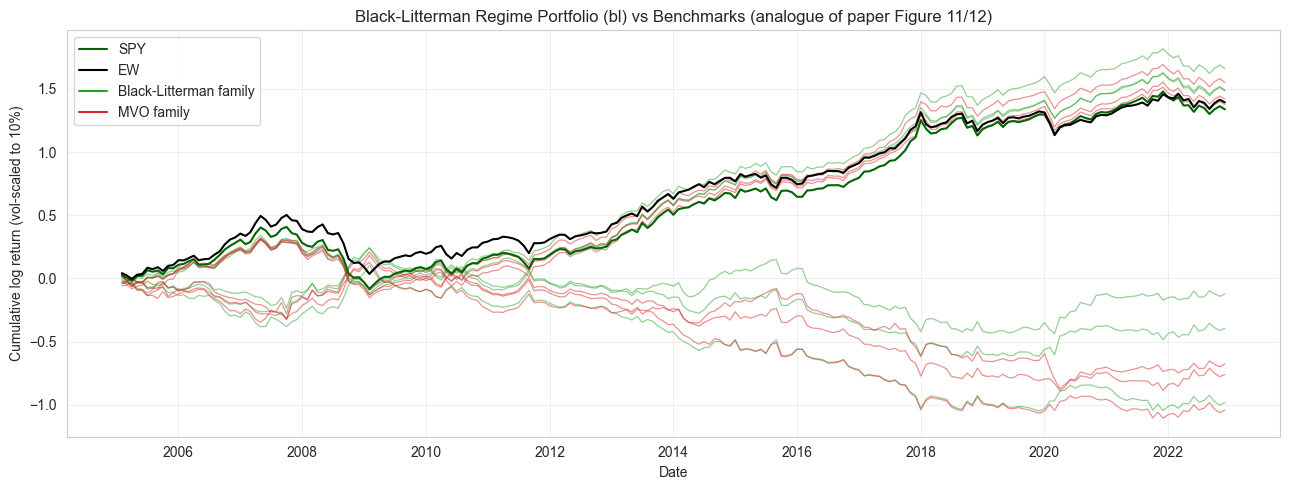

In [401]:
# Figure 12 analogue: Black-Litterman cumulative log returns vs MVO and benchmarks
plot_family_vs_benchmarks('bl', 'C2', 'Black-Litterman')

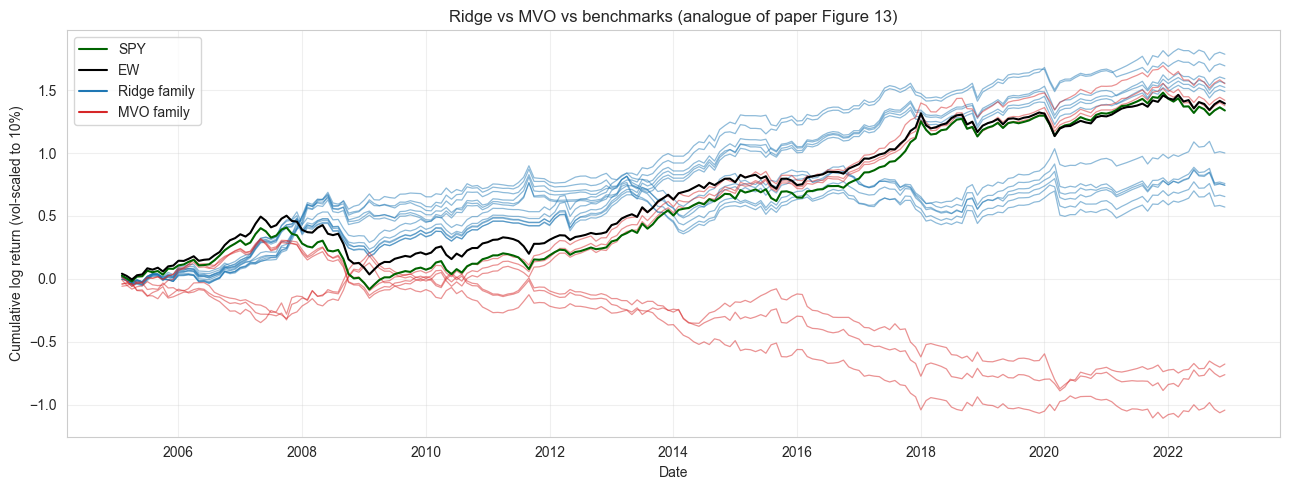

In [402]:
# Ridge family vs MVO and benchmarks (paper Figure 13 analogue).
fig, ax = plt.subplots(figsize=(13, 5))
for col in bt_returns_scaled.columns:
    if col.startswith('ridge_'):
        cum = np.log1p(bt_returns_scaled[col]).cumsum()
        ax.plot(cum.index, cum.values, color='C0', alpha=0.5, linewidth=0.9)
for col in bt_returns_scaled.columns:
    if col.startswith('mvo_'):
        cum = np.log1p(bt_returns_scaled[col]).cumsum()
        ax.plot(cum.index, cum.values, color='C3', alpha=0.5, linewidth=0.9)
for col, color in [('spy', 'darkgreen'), ('ew', 'k')]:
    if col in bt_returns_scaled.columns:
        cum = np.log1p(bt_returns_scaled[col]).cumsum()
        ax.plot(cum.index, cum.values, color=color, linewidth=1.5, label=col.upper())

ax.plot([], [], color='C0', label='Ridge family')
ax.plot([], [], color='C3', label='MVO family')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative log return (vol-scaled to 10%)')
ax.set_title('Ridge vs MVO vs benchmarks (analogue of paper Figure 13)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


## 23. Replication status and deviation log

This notebook implements the Oliveira et al. methodology as closely as possible from the information available in the paper.

### Matched components

- FRED-MD transformation codes applied.
- PCA used at the 95% explained-variance threshold.
- Modified k-means implemented as L2 outlier split followed by cosine k-means.
- Soft regime probabilities computed from centroid distances.
- Transition matrix and Markov next-regime update implemented.
- Naive, Black-Litterman, Ridge, and MVO models implemented.
- Long-only, long-and-short, long-or-short, and mixed sizing schemes implemented.
- 48-month fixed-window, one-month-ahead backtest implemented.
- EW and SPY benchmarks included.
- Random-regime controls added.

### Remaining implementation choices / deviations

- The paper is internally inconsistent about Group 6: it says Group 6 is excluded, but Figure 4 uses FEDFUNDS, and the reported 61 PCA components are matched in this vintage only when Group 6 is kept.
- The paper states February 2000 to December 2022 for ETFs but also reports 746 monthly observations; those cannot both be true.
- Missing-value handling is not fully specified in the paper; this notebook uses forward/backward filling after transformation and reports it explicitly.
- The exact Black-Litterman choices for the pick matrix, view uncertainty matrix, and final optimizer are not fully specified; this notebook uses a transparent implementation with P = I and Omega = diag(tau Sigma).
- Random-regime generation details are not fully specified; this notebook preserves within-window regime counts by permuting labels.

### Not included here

- SJM teacher labels.
- GP classifier.
- 60/40 equity-bond tactical overlay.
- Macro publication lag adjustment.


# Try Other Regime Labelling

To investigate, we re-run Part B with two alternative regime labellers, keeping everything else identical:

1. **NBER recessions as Regime 0** (sanity check). Two regimes total: recession or expansion. The simplest possible "ground truth" stress regime, definitely has no outlier-sensitivity problem.
2. **Skip the L2 step, use 6-cluster cosine k-means directly** (the main alternative). Six regimes total. This tests whether the paper's pipeline works *if* we replace the fragile L2 step with a cleaner partition.

We compare all three labellers (paper / NBER-binary / cosine-only) on the same set of strategies, asset-sizing schemes, and backtest window. Any *qualitative* differences across labellers tell us how sensitive the paper's results are to the choice of regime detector.

**Important caveat.** The paper does not publish its regime labels, so we cannot literally substitute *their* labels. We can only substitute *alternative* labels and see how the pipeline responds. This still tells us a lot about robustness.

## 1 NBER-based binary labeller

We define a binary regime: Regime 0 if month $t$ is in an NBER-defined recession, else Regime 1. We then refit a 2-by-2 transition matrix at each rolling window. Soft probabilities are degenerate (one-hot encoding of the NBER label).

This is a sanity check, not a serious competing methodology.

In [403]:
def make_nber_label_series(dates):
    '''Return a Series of {0, 1} labels indexed by `dates`, where 0 = NBER recession.'''
    nber_months = set()
    for peak, trough in NBER_RECESSIONS:
        nber_months.update(pd.date_range(peak, trough, freq='MS'))
    labels = pd.Series(1, index=dates, dtype=int)  # default = expansion
    in_nber = labels.index.isin(nber_months)
    labels[in_nber] = 0
    return labels


def fit_regime_window_nber(X_window_unused, window_dates, n_typical=1, seed=42):
    '''
    Build a 'regime fit' from NBER recession dating instead of macro clustering.

    Returns the same dict shape as fit_regime_window() so the rest of the pipeline
    can use it unchanged. Two regimes total (n_typical = 1 means R0 + R1).
    '''
    n_total = n_typical + 1   # = 2
    nber_labels = make_nber_label_series(window_dates).values

    # Soft probabilities are one-hot.
    probs = np.zeros((len(nber_labels), n_total))
    for t, lab in enumerate(nber_labels):
        probs[t, lab] = 1.0

    return {
        'labels': nber_labels.astype(int),
        'probs': probs,
        'transition': transition_matrix(nber_labels, n_total),
        'centroids_cos': None,
        'window_dates': window_dates,
    }


def run_walk_forward_nber(macro_panel, window=48):
    '''Walk-forward NBER labelling - macro panel is unused but kept for API compatibility.'''
    rolling = {}
    dates = macro_panel.index
    for end_idx in range(window, len(dates) + 1):
        window_dates = dates[end_idx - window : end_idx]
        rolling[window_dates[-1]] = fit_regime_window_nber(None, window_dates, n_typical=1)
    return rolling


print("Building NBER-based rolling regime fits...")
rolling_nber = run_walk_forward_nber(data_macro_aligned, window=ESTIMATION_WINDOW)
print(f"  {len(rolling_nber)} decision dates")

# Sanity check: how many NBER recession months are in each window?
nber_in_windows = [(rolling_nber[d]['labels'] == 0).sum() for d in sorted(rolling_nber.keys())]
print(f"  NBER recession months per window: min={min(nber_in_windows)}, "
      f"max={max(nber_in_windows)}, mean={np.mean(nber_in_windows):.1f}")


Building NBER-based rolling regime fits...
  228 decision dates
  NBER recession months per window: min=0, max=19, mean=5.2


## 2 Cosine-only labeller (skip the L2 step)

We replace the two-stage L2-then-cosine procedure with a single-stage **6-cluster cosine k-means** on the PCA-reduced macro features. Same number of regimes as the paper, no Regime 0 outlier, all 6 regimes treated symmetrically.

In [404]:
def fit_regime_window_cosine_only(X_window, n_regimes=6, var_threshold=0.95, seed=42):
    '''
    Single-stage cosine k-means on PCA features. No L2 outlier step.

    Returns the same dict shape as fit_regime_window() so the backtest can
    use it unchanged.
    '''
    # PCA
    pca_full = PCA(random_state=seed).fit(X_window)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)
    n_pc = max(2, int(np.searchsorted(cum_var, var_threshold) + 1))
    pca = PCA(n_components=n_pc, random_state=seed).fit(X_window)
    X_pca = pca.transform(X_window)

    # Cosine k-means: L2-normalize then standard k-means.
    X_unit = l2_normalize_rows(X_pca)
    km = KMeans(n_clusters=n_regimes, n_init=10, random_state=seed).fit(X_unit)
    cos_dists = km.transform(X_unit)
    probs = distances_to_probs_eq1(cos_dists)
    labels = km.labels_

    return {
        'labels': labels.astype(int),
        'probs': probs,
        'transition': transition_matrix(labels, n_regimes),
        'centroids_cos': km.cluster_centers_,
    }


def run_walk_forward_cosine_only(macro_panel, window=48, n_regimes=6, seed=42, verbose_every=50):
    '''Walk-forward cosine-only regime detection.'''
    rolling = {}
    dates = macro_panel.index
    for end_idx in range(window, len(dates) + 1):
        start_idx = end_idx - window
        window_dates = dates[start_idx:end_idx]
        decision_date = window_dates[-1]
        X_win = macro_panel.iloc[start_idx:end_idx].values
        X_std_w = StandardScaler().fit_transform(X_win)
        result = fit_regime_window_cosine_only(X_std_w, n_regimes=n_regimes, seed=seed)
        result['window_dates'] = window_dates
        rolling[decision_date] = result
        if verbose_every and (end_idx - window) % verbose_every == 0:
            print(f"  decision date {decision_date.date()}: "
                  f"label distribution {np.bincount(result['labels'], minlength=n_regimes).tolist()}")
    return rolling


print("Building cosine-only rolling regime fits...")
rolling_cosine = run_walk_forward_cosine_only(
    data_macro_aligned, window=ESTIMATION_WINDOW, n_regimes=N_TYPICAL_REGIMES + 1,
    seed=RANDOM_SEED, verbose_every=50,
)
print(f"\nDone. {len(rolling_cosine)} decision dates.")


Building cosine-only rolling regime fits...
  decision date 2004-01-01: label distribution [10, 11, 6, 9, 7, 5]
  decision date 2008-03-01: label distribution [5, 8, 13, 5, 11, 6]
  decision date 2012-05-01: label distribution [11, 5, 10, 9, 6, 7]
  decision date 2016-07-01: label distribution [13, 10, 8, 4, 10, 3]
  decision date 2020-09-01: label distribution [4, 11, 6, 8, 9, 10]

Done. 228 decision dates.


## 3 Re-run the backtest under each alternative labeller

We pass the alternative `rolling_regimes` dicts into the same `walk_forward_backtest` function used in Part B. The backtest function depends on the regime structure only via `n_typical_regimes`, so we adjust that parameter accordingly:

- NBER labeller: `n_typical_regimes = 1` (so n_total = 2: R0 = recession, R1 = expansion)
- Cosine-only labeller: `n_typical_regimes = 5` (so n_total = 6, same as paper). Note: when we skip the L2 step there is no special "Regime 0". All 6 cosine clusters are equally valid. But the backtest treats `i = 0` as the "crisis" regime for the `mx` (mixed) sizing scheme. With cosine-only, "regime 0" is just whichever cluster scikit-learn happened to label 0, **not** a meaningful crisis indicator. The `mx` results under cosine-only labeller should be interpreted with this caveat in mind.

In [405]:
print("Running backtest under NBER labeller...")
bt_returns_nber = walk_forward_backtest(
    etf_returns_aligned, data_macro_aligned, rolling_nber,
    n_typical_regimes=1, l_grid=(2, 3, 4),
)
bt_returns_nber_scaled = vol_scale(bt_returns_nber, target_annual_vol=0.10, lookback=12).dropna(how='all')
print(f"  Backtest output: {bt_returns_nber.shape}")

print("\nRunning backtest under cosine-only labeller...")
bt_returns_cosine = walk_forward_backtest(
    etf_returns_aligned, data_macro_aligned, rolling_cosine,
    n_typical_regimes=N_TYPICAL_REGIMES, l_grid=(2, 3, 4),
)
bt_returns_cosine_scaled = vol_scale(bt_returns_cosine, target_annual_vol=0.10, lookback=12).dropna(how='all')
print(f"  Backtest output: {bt_returns_cosine.shape}")


Running backtest under NBER labeller...
  Backtest output: (227, 38)

Running backtest under cosine-only labeller...
  Backtest output: (227, 38)


## 4 Comparison

We compute metrics for all three labeller variants and stack them into one table. For each strategy family (Naive, Ridge, BL), we look at the long-only with $\mathcal{l}=3$ as a representative (this is broadly what wins under the paper's analysis).

Benchmarks SPY and EW are identical across all three runs by construction, so they appear once.

In [406]:
metrics_paper = compute_metrics(bt_returns_scaled)
metrics_nber = compute_metrics(bt_returns_nber_scaled)
metrics_cosine = compute_metrics(bt_returns_cosine_scaled)


def stack_comparison(metric_name, strategies):
    '''Build a comparison DataFrame for one metric across three labellers.'''
    rows = []
    for s in strategies:
        row = {'strategy': s}
        if s in metrics_paper.index:
            row['paper_L2_cos'] = metrics_paper.loc[s, metric_name]
        if s in metrics_nber.index:
            row['nber_binary'] = metrics_nber.loc[s, metric_name]
        if s in metrics_cosine.index:
            row['cosine_only'] = metrics_cosine.loc[s, metric_name]
        rows.append(row)
    return pd.DataFrame(rows).set_index('strategy').round(3)


# Pick one representative strategy per family per sizing scheme.
# Focus on lo (long-only) variants since the paper finds these strongest.
strategies_to_compare = [
    'naive_lo_2', 'naive_lo_3', 'naive_lo_4',
    'ridge_lo_2', 'ridge_lo_3', 'ridge_lo_4',
    'bl_lo_2', 'bl_lo_3', 'bl_lo_4',
    'mvo_lo_2', 'mvo_lo_3', 'mvo_lo_4',
    'spy', 'ew',
]

print("=== SHARPE RATIO across regime labellers (long-only strategies) ===\n")
print(stack_comparison('Sharpe', strategies_to_compare))

print("\n=== SORTINO RATIO across regime labellers (long-only strategies) ===\n")
print(stack_comparison('Sortino', strategies_to_compare))

print("\n=== MAX DRAWDOWN (%) across regime labellers (long-only strategies) ===\n")
print(stack_comparison('MaxDD', strategies_to_compare))


=== SHARPE RATIO across regime labellers (long-only strategies) ===

            paper_L2_cos  nber_binary  cosine_only
strategy                                          
naive_lo_2         0.804        0.833        0.776
naive_lo_3         0.843        0.879        0.766
naive_lo_4         0.848        0.871        0.782
ridge_lo_2         0.907        0.797        0.573
ridge_lo_3         0.782        0.815        0.560
ridge_lo_4         0.815        0.804        0.559
bl_lo_2            0.845        0.807        0.878
bl_lo_3            0.762        0.692        0.795
bl_lo_4            0.760        0.742        0.786
mvo_lo_2           0.799        0.799        0.799
mvo_lo_3           0.707        0.707        0.707
mvo_lo_4           0.729        0.729        0.729
spy                0.678        0.678        0.678
ew                 0.703        0.703        0.703

=== SORTINO RATIO across regime labellers (long-only strategies) ===

            paper_L2_cos  nber_binary  cosin

In [407]:
# Also do a long-short comparison so we can see whether our choice of labeller
# affects the long-short underperformance pattern.
strategies_lns = [
    'naive_lns_3', 'ridge_lns_3', 'bl_lns_3', 'mvo_lns_3',
    'naive_los_3', 'ridge_los_3',
    'naive_mx_3', 'ridge_mx_3',
]
print("=== SHARPE RATIO across regime labellers (long-short strategies, l=3) ===\n")
print(stack_comparison('Sharpe', strategies_lns))


=== SHARPE RATIO across regime labellers (long-short strategies, l=3) ===

             paper_L2_cos  nber_binary  cosine_only
strategy                                           
naive_lns_3         0.700        0.920        0.579
ridge_lns_3         0.313        0.227        0.308
bl_lns_3           -0.119       -0.361       -0.053
mvo_lns_3          -0.296       -0.296       -0.296
naive_los_3         0.699        0.942        0.689
ridge_los_3         0.408        0.205        0.284
naive_mx_3          0.761        0.940        0.726
ridge_mx_3          0.778        0.745        0.534


## Visual comparison: cumulative returns of the best strategy under each labeller

We plot cumulative log returns of `ridge_lo_3` under each of the three regime labellers, with SPY as the reference benchmark.

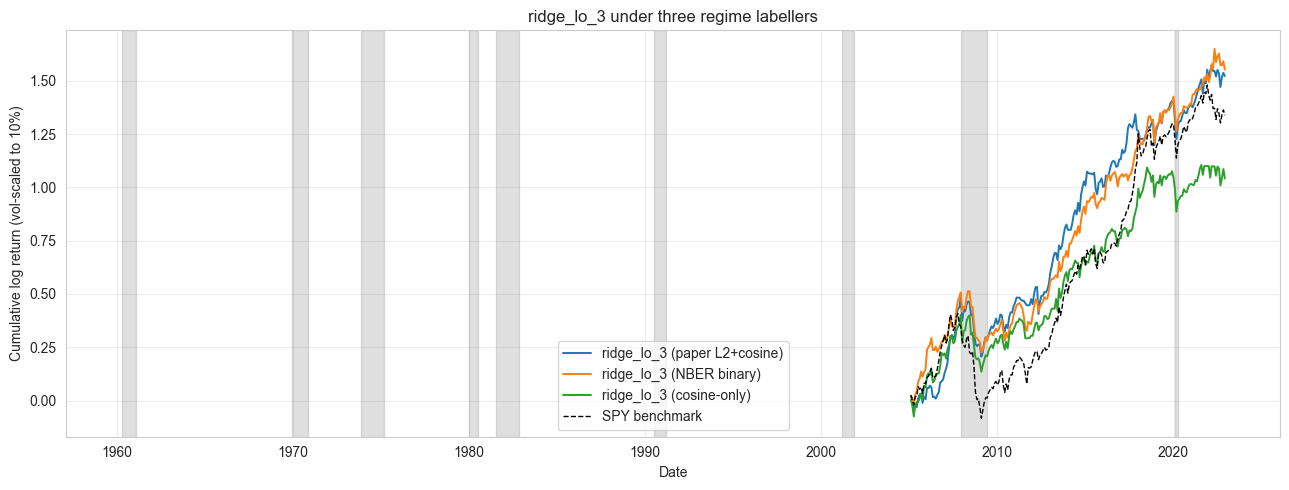

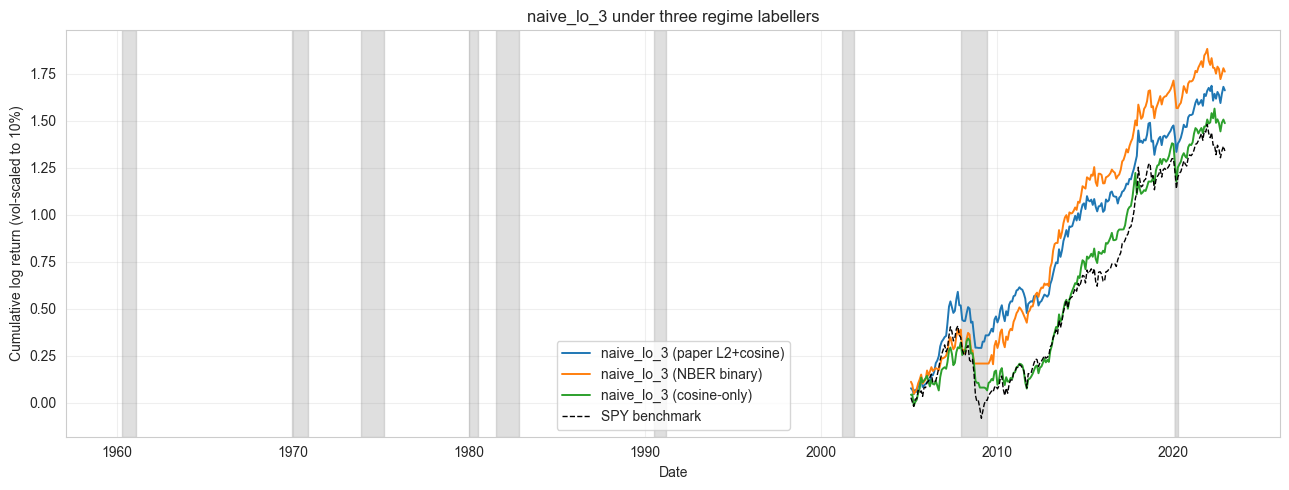

In [408]:
def plot_labeller_comparison(strategy_name, dataframes, labels, title=''):
    '''Cumulative-log-return overlay across the three labellers for one strategy.'''
    fig, ax = plt.subplots(figsize=(13, 5))
    colors = ['C0', 'C1', 'C2']
    for df, lbl, color in zip(dataframes, labels, colors):
        if strategy_name in df.columns:
            cum = np.log1p(df[strategy_name]).cumsum()
            ax.plot(cum.index, cum.values, color=color, linewidth=1.4,
                    label=f'{strategy_name} ({lbl})')
    # Add SPY benchmark from the first (paper) backtest.
    if 'spy' in dataframes[0].columns:
        spy_cum = np.log1p(dataframes[0]['spy']).cumsum()
        ax.plot(spy_cum.index, spy_cum.values, color='black', linewidth=1.0,
                linestyle='--', label='SPY benchmark')
    shade_nber(ax)
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative log return (vol-scaled to 10%)')
    ax.set_title(title)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()


plot_labeller_comparison(
    'ridge_lo_3',
    [bt_returns_scaled, bt_returns_nber_scaled, bt_returns_cosine_scaled],
    ['paper L2+cosine', 'NBER binary', 'cosine-only'],
    title='ridge_lo_3 under three regime labellers',
)

plot_labeller_comparison(
    'naive_lo_3',
    [bt_returns_scaled, bt_returns_nber_scaled, bt_returns_cosine_scaled],
    ['paper L2+cosine', 'NBER binary', 'cosine-only'],
    title='naive_lo_3 under three regime labellers',
)
